<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/Nano3-seq%20analysis/DifferentialPolyadenylationPlots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Differential Polyadenylation Plotting

This notebook is organized by the comparison being made and includes the following types of plots:


*   Differential polyadenylation vs differential gene expression
*   Differential polyadenylation vs counts
* Over-representation analysis
* Poly(A) tail length distribution historgrams
* Beeswarm plots




## Normoxia 6 hpf *tent5ba*+/+ to Hypoxia 18 hrs *tent5ba*+/+

### Differential polyadenylation vs differential gene expression

In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/content/drive/MyDrive/Chris/Nano3pSeq'  #change dir to your project folder

Mounted at /content/drive/


In [ ]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 26.9 MB/s eta 0:00:00


In [ ]:
# import libraries
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from glob import glob
from scipy import stats


In [ ]:
# import differential gene expression results from Bulk RNA-seq of Normoxia 6 hpf tent5ba+/+ to Hypoxia 18 hrs tent5ba+/+

bulk = pd.read_csv(data_path + '/Hypoxia_18hrs_WTVsNormoxia_6hpf_WTDGEGenesAll.csv')
bulk = bulk.rename(columns = {"genes":"Gene"})
bulk1 = bulk.drop(['lfcSE', 'stat', 'pvalue'], axis = 1)
bulk1

,Gene,baseMean,log2FoldChange,padj
0,ABCD2,1.683824,-0.680467,0.614306
1,ACKR2,0.234931,0.151715,NaN
2,ACOT12,11.634294,-0.420805,0.727642
3,ACSF3,5.289976,-0.818515,0.119206
4,ACVR1C,1.157447,0.454144,0.754795
...,...,...,...,...
25981,zwilch,56.519713,-0.970507,0.000028
25982,zyg11,85.291477,-0.001915,0.995791
25983,zyx,491.649188,0.261424,0.017567
25984,zzef1,114.790224,-0.617002,0.000002


In [ ]:
# import differential polyadenylation results from Nano3p-seq of Normoxia 6 hpf tent5ba+/+ to Hypoxia 18 hrs tent5ba+/+

merged = pd.read_csv(data_path + '/N6WTvsH18WT_Stats/ByCondition_20reads.csv')

In [ ]:
 merged

,Gene,Avg_N6WT_Adjusted_pt_length,Avg_H18WT_Adjusted_pt_length,p_value,n_N6WT,n_H18WT,BH_adjusted_p_value,log2FC_H18WT_vs_N6WT,delta_pT_H18WT_vs_N6WT
0,hmgb2a,131.362889,76.989159,0.000000,7689,11899,0.0,-0.770831,-54.373730
1,anp32e,126.499918,65.542837,0.000000,3035,5979,0.0,-0.948626,-60.957080
2,nucks1a,138.143071,83.067442,0.000000,2172,2782,0.0,-0.733808,-55.075628
3,si:ch211-222l21.1,126.770815,83.689853,0.000000,3357,6455,0.0,-0.599098,-43.080962
4,BX088707.1,97.156291,56.092939,0.000000,3795,10176,0.0,-0.792488,-41.063352
...,...,...,...,...,...,...,...,...,...
6949,hnmt,38.673077,41.922619,1.000000,26,21,1.0,0.116399,3.249542
6950,dsn1,67.107383,56.668527,0.999339,149,112,1.0,-0.243924,-10.438856
6951,abhd14b,66.786111,59.767361,1.000000,45,36,1.0,-0.160190,-7.018750
6952,cbll1,77.500000,67.618902,1.000000,23,41,1.0,-0.196770,-9.881098


In [ ]:
# Merge on Gene
merged = merged.merge(bulk1, on="Gene", how="left")

# Rename columns
merged = merged.rename(columns={
    "baseMean":"baseMeanBulk",
    "log2FoldChange":"log2FoldChangeBulk",
    "padj":"padjBulk"
})

# Now merged contains both tables combined
merged.head()

,Gene,Avg_N6WT_Adjusted_pt_length,Avg_H18WT_Adjusted_pt_length,p_value,n_N6WT,n_H18WT,BH_adjusted_p_value,log2FC_H18WT_vs_N6WT,delta_pT_H18WT_vs_N6WT,baseMeanBulk,log2FoldChangeBulk,padjBulk
0,hmgb2a,131.362889,76.989159,0.0,7689,11899,0.0,-0.770831,-54.373730,16498.949807,0.343418,0.087133
1,anp32e,126.499918,65.542837,0.0,3035,5979,0.0,-0.948626,-60.957080,10335.819826,0.234526,0.219211
2,nucks1a,138.143071,83.067442,0.0,2172,2782,0.0,-0.733808,-55.075628,8409.145265,0.254682,0.322027
3,si:ch211-222l21.1,126.770815,83.689853,0.0,3357,6455,0.0,-0.599098,-43.080962,10669.041139,0.720751,0.003024
4,BX088707.1,97.156291,56.092939,0.0,3795,10176,0.0,-0.792488,-41.063352,2679.008967,0.193967,0.910863


Total points: 1554, Valid points: 1554
Pearson r = 0.001, p = 9.694e-01


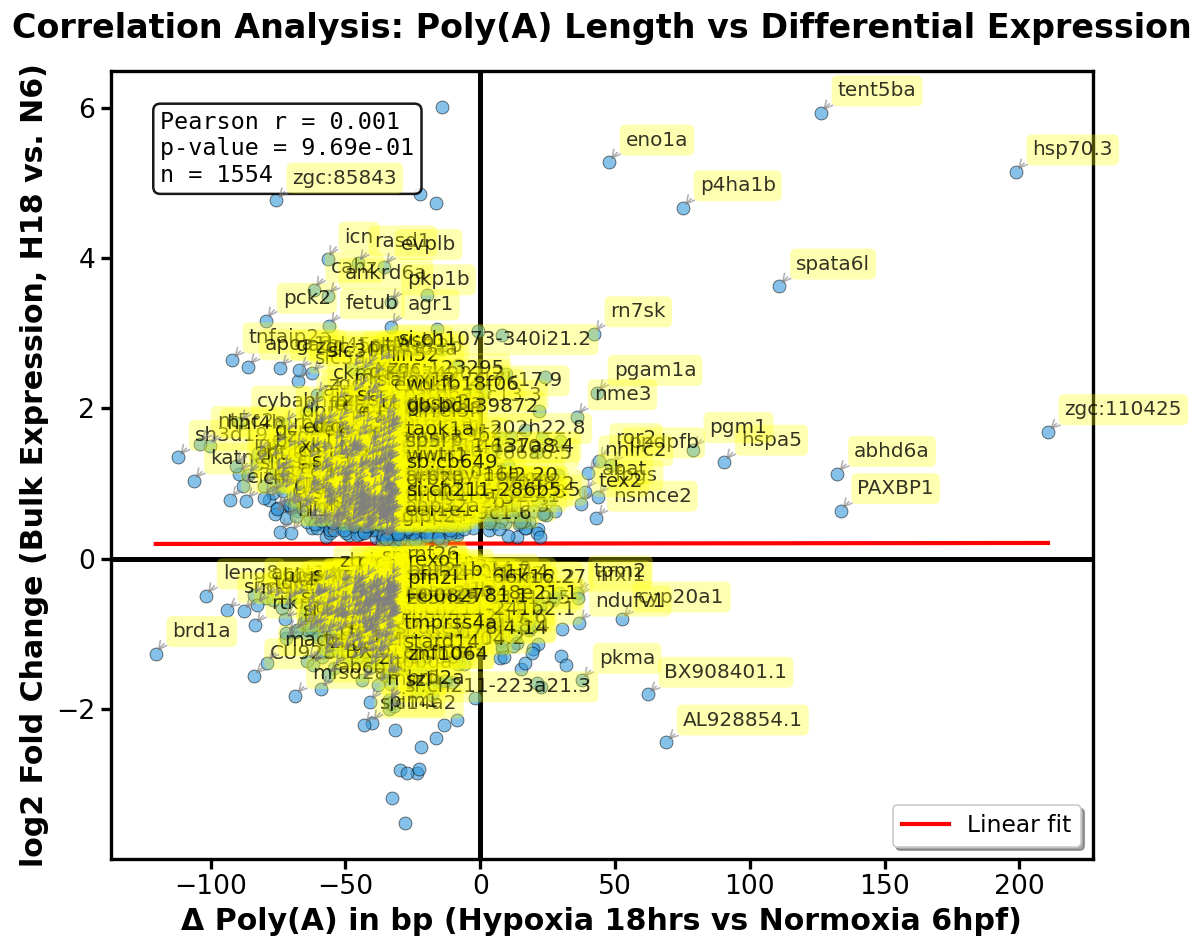


✓ Enhanced plot created with 1554 data points
✓ Correlation coefficient: r = 0.001
✓ Statistical significance: p = 9.69e-01


In [ ]:
# plot with some gene labels

# Filter by adjusted p-value
filtered = merged.copy()
filtered = merged[merged['BH_adjusted_p_value'] <= 0.05]
filtered = filtered[filtered['padjBulk'] <= 0.05]

# Extract the two series and remove NaN values
x = filtered["delta_pT_H18WT_vs_N6WT"]
y = filtered["log2FoldChangeBulk"]

# Create a mask for non-NaN values in both series
valid_mask = x.notna() & y.notna()
x_clean = x[valid_mask]
y_clean = y[valid_mask]

print(f"Total points: {len(filtered)}, Valid points: {len(x_clean)}")

# Pearson correlation
r, pval = stats.pearsonr(x_clean, y_clean)
print(f"Pearson r = {r:.3f}, p = {pval:.3e}")

# Create figure with white background
fig, ax = plt.subplots(figsize=(10, 8), dpi=120, facecolor='white')
ax.set_facecolor('white')

# Main scatter plot - single color
scatter = ax.scatter(x_clean, y_clean,
                     c='#3498DB',
                     alpha=0.6,
                     s=60,
                     edgecolor='black',
                     linewidth=0.5,
                     zorder=3)

# Regression line
m, b = np.polyfit(x_clean, y_clean, 1)
x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
y_line = m * x_line + b

ax.plot(x_line, y_line, color='red', linestyle='-', linewidth=2.5,
        label='Linear fit', zorder=2)

# Reference lines
ax.axhline(0, color='black', linestyle='-', linewidth=3, zorder=1)
ax.axvline(0, color='black', linestyle='-', linewidth=3, zorder=1)


# Labels and title
ax.set_xlabel('Δ Poly(A) in bp (Hypoxia 18hrs vs Normoxia 6hpf)', fontsize=18, fontweight='bold')
ax.set_ylabel('log2 Fold Change (Bulk Expression, H18 vs. N6)', fontsize=18, fontweight='bold')
ax.set_title('Correlation Analysis: Poly(A) Length vs Differential Expression',
             fontsize=20, fontweight='bold', pad=20)

# Add statistics box
stats_text = f'Pearson r = {r:.3f}\np-value = {pval:.2e}\nn = {len(x_clean)}'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=1.5)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props, family='monospace')

# Add gene labels for points far from origin (top 700 most extreme)
distances = np.sqrt(x_clean**2 + y_clean**2)
top_indices = distances.nlargest(700).index

for idx in top_indices:
    gene = filtered.loc[idx, "Gene"]
    xi = x.loc[idx]
    yi = y.loc[idx]
    ax.annotate(gene,
                xy=(xi, yi),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=12,
                alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3, edgecolor='none'),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                               color='gray', alpha=0.6, lw=1))

# Legend
ax.legend(loc='lower right', frameon=True, fancybox=True, shadow=True, fontsize=14)

# Make axes black and thicker
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

# Larger tick labels
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6, color='black')

# Remove grid
ax.grid(False)

plt.savefig(data_path + '/NormVsHyp_pt_lengthvsAbundance_AllLabelsreads20.png', dpi=600, bbox_inches='tight')


# Tight layout
plt.tight_layout()
plt.show()

print(f"\n Enhanced plot created with {len(x_clean)} data points")
print(f"Correlation coefficient: r = {r:.3f}")
print(f"Statistical significance: p = {pval:.2e}")

Total points: 1554, Valid points: 1554
Pearson r = 0.001, p = 9.694e-01


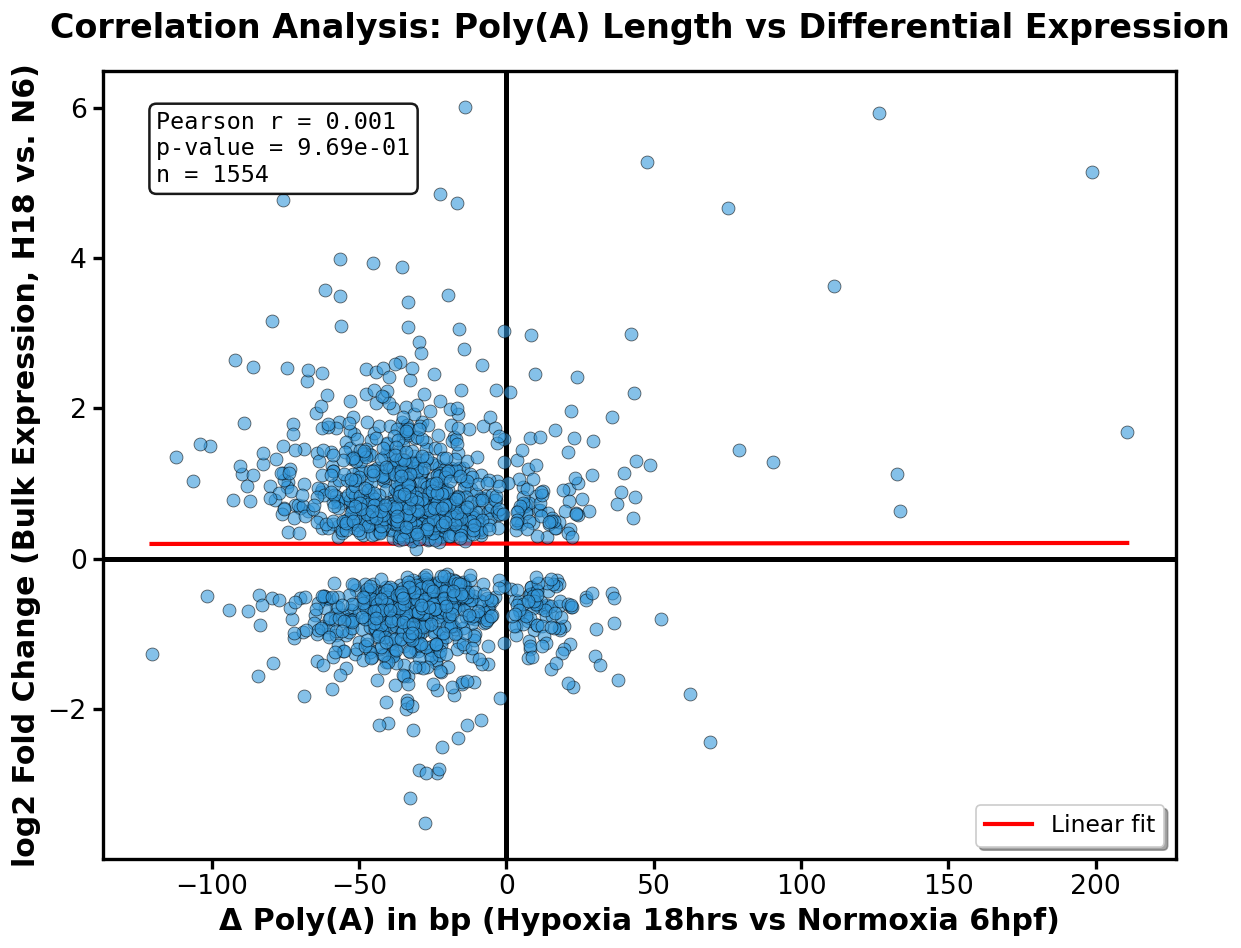


✓ Enhanced plot created with 1554 data points
✓ Correlation coefficient: r = 0.001
✓ Statistical significance: p = 9.69e-01


In [ ]:
# Plot without gene labels

# Filter by adjusted p-value
filtered = merged.copy()
filtered = merged[merged['BH_adjusted_p_value'] <= 0.05]
filtered = filtered[filtered['padjBulk'] <= 0.05]

# Extract the two series and remove NaN values
x = filtered["delta_pT_H18WT_vs_N6WT"]
y = filtered["log2FoldChangeBulk"]

# Create a mask for non-NaN values in both series
valid_mask = x.notna() & y.notna()
x_clean = x[valid_mask]
y_clean = y[valid_mask]

print(f"Total points: {len(filtered)}, Valid points: {len(x_clean)}")

# Pearson correlation
r, pval = stats.pearsonr(x_clean, y_clean)
print(f"Pearson r = {r:.3f}, p = {pval:.3e}")

# Create figure with white background
fig, ax = plt.subplots(figsize=(10, 8), dpi=120, facecolor='white')
ax.set_facecolor('white')

# Main scatter plot - single color
scatter = ax.scatter(x_clean, y_clean,
                     c='#3498DB',
                     alpha=0.6,
                     s=60,
                     edgecolor='black',
                     linewidth=0.5,
                     zorder=3)

# Regression line
m, b = np.polyfit(x_clean, y_clean, 1)
x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
y_line = m * x_line + b

ax.plot(x_line, y_line, color='red', linestyle='-', linewidth=2.5,
        label='Linear fit', zorder=2)

# Reference lines
ax.axhline(0, color='black', linestyle='-', linewidth=3, zorder=1)
ax.axvline(0, color='black', linestyle='-', linewidth=3, zorder=1)


# Labels and title
ax.set_xlabel('Δ Poly(A) in bp (Hypoxia 18hrs vs Normoxia 6hpf)', fontsize=18, fontweight='bold')
ax.set_ylabel('log2 Fold Change (Bulk Expression, H18 vs. N6)', fontsize=18, fontweight='bold')
ax.set_title('Correlation Analysis: Poly(A) Length vs Differential Expression',
             fontsize=20, fontweight='bold', pad=20)

# Add statistics box
stats_text = f'Pearson r = {r:.3f}\np-value = {pval:.2e}\nn = {len(x_clean)}'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=1.5)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props, family='monospace')



# Legend
ax.legend(loc='lower right', frameon=True, fancybox=True, shadow=True, fontsize=14)

# Make axes black and thicker
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

# Larger tick labels
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6, color='black')

# Remove grid
ax.grid(False)

plt.savefig(data_path + 'NormVsHyp_pt_lengthvsAbundance_Nolabels_reads20.png', dpi=600, bbox_inches='tight')


# Tight layout
plt.tight_layout()
plt.show()

print(f"\n Enhanced plot created with {len(x_clean)} data points")
print(f" Correlation coefficient: r = {r:.3f}")
print(f" Statistical significance: p = {pval:.2e}")

### Over-representation analysis

#### Genes that decrease their poly(A) tails and are down regulated in hypoxia

In [ ]:
# filter
sig = ((merged['BH_adjusted_p_value'] <= 0.05) & (merged['delta_pT_H18WT_vs_N6WT'] < -5) & (merged['padjBulk'] <= 0.05) & (merged['log2FoldChangeBulk'] < -0.5))
genes_down = merged[sig]
genes_down

,Unnamed: 0,Gene,Avg_N6WT_Adjusted_pt_length,Avg_H18WT_Adjusted_pt_length,p_value,n_N6WT,n_H18WT,BH_adjusted_p_value,log2FC_H18WT_vs_N6WT,delta_pT_H18WT_vs_N6WT,baseMeanBulk,log2FoldChangeBulk,padjBulk
30,30,mt-cyb,62.226236,32.557704,1.546712e-271,4692,847,3.469624e-269,-0.934524,-29.668532,4089.466939,-2.819361,1.762704e-27
37,37,mt-co2,67.133260,43.488527,3.826181e-218,10533,937,7.001912e-216,-0.626393,-23.644733,4075.947674,-2.846238,2.192035e-23
44,44,ucp2,95.633127,41.285848,2.930616e-182,1492,938,4.528778e-180,-1.211863,-54.347279,1554.002768,-1.452094,4.359749e-06
59,59,srsf3a,136.038073,82.660446,4.770613e-137,916,864,5.529140e-135,-0.718741,-53.377628,2468.101562,-0.735879,2.818986e-02
67,67,COX3,62.065051,34.303896,2.312546e-121,3013,385,2.364918e-119,-0.855409,-27.761155,9142.218253,-3.514146,1.046045e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,3682,znf1113,81.383065,46.285256,2.429525e-02,31,39,4.587271e-02,-0.814176,-35.097808,240.475053,-0.849904,5.691383e-04
3697,3697,mthfd2,95.362500,63.732759,2.504178e-02,40,58,4.709046e-02,-0.581387,-31.629741,315.218882,-0.873005,2.499405e-02
3707,3707,trim25l,87.291667,55.153090,2.565576e-02,75,89,4.811493e-02,-0.662402,-32.138577,264.041087,-0.990785,8.999846e-03
3718,3718,exosc9,79.411458,50.594907,2.630505e-02,96,108,4.918065e-02,-0.650355,-28.816551,126.671717,-0.614264,2.539373e-05


In [ ]:
# Take a peak at the list
genes_down = genes_down['Gene'].to_list()

In [ ]:
genes_down

['mt-cyb',
 'mt-co2',
 'ucp2',
 'srsf3a',
 'COX3',
 'mt-co1',
 'rrm2',
 'mt-nd1',
 'acer1',
 'ptp4a1',
 'hsd17b12a',
 'si:ch1073-80i24.3',
 'calm2a',
 'rbbp4',
 'si:dkeyp-67a8.4',
 'g3bp1',
 'sox19a',
 'dnaja2a',
 'eny2',
 'pfn2l',
 'slc2a12',
 'mat2aa',
 'ctcf',
 'rbm12',
 'nnr',
 'mych',
 'pcdh1b',
 'glulb',
 'pdcd10b',
 'zgc:91849',
 'lrrc15',
 'si:dkey-160o24.3',
 'mapk6',
 'rcc1',
 'mt-nd5',
 's100a1',
 'snrpb2',
 'abcf2a',
 'ccna2',
 'dhrs13a.2',
 'sap30bp',
 'slc35f6',
 'tmpob',
 'skp1',
 'btg2',
 'slc26a1',
 'marcksa',
 'ythdf2',
 'adssl',
 'acin1b',
 'znf569l',
 'stard14',
 'slc25a55a',
 'pcca',
 'ptbp1a',
 'sema4bb',
 'slc43a1a',
 'strip1',
 'lrrc8c',
 'trnau1apb',
 'BX530721.1',
 'mt-nd6',
 'nasp',
 'zfand5b',
 'dynlrb1',
 'zgc:56676',
 'mcrs1',
 'znf1035',
 'degs2',
 'si:ch73-160h15.3',
 'si:ch211-66k16.27',
 'si:dkeyp-100a1.6',
 'golt1bb',
 'med7',
 'plk3',
 'gtf2h5',
 'dhfr',
 'amd1',
 'cdk2',
 'b4galt6',
 'zgc:56106',
 'sat1a.2',
 'ifi45',
 'rnf145b',
 'hnrnpr',
 'slc30a

In [ ]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 12.5 MB/s eta 0:00:00


In [ ]:
import gseapy as gp

# WikiPathways
enr_wp = gp.enrichr(
    gene_list=genes_down,
    gene_sets=['WikiPathways_2018'],
    organism='danio rerio',
    outdir='enrichr_wikipathways',
    cutoff=1
)

# GO Biological Process
enr_go = gp.enrichr(
    gene_list=genes_down,
    gene_sets=['GO_Biological_Process_2018'],
    organism='danio rerio',
    outdir='enrichr_go',
    cutoff=1
)

# KEGG
enr_kegg = gp.enrichr(
    gene_list=genes_down,
    gene_sets=['KEGG_2019'],
    organism='danio rerio',
    outdir='enrichr_kegg',
    cutoff=1
)


# GO Biological Process
enr_goc = gp.enrichr(
    gene_list=genes_down,
    gene_sets=['GO_Cellular_Component_2018'],
    organism='danio rerio',
    outdir='enrichr_go',
    cutoff=1
)


In [ ]:
results_wp = enr_wp.results
results_go = enr_go.results
results_kegg = enr_kegg.results
results_goc = enr_goc.results

In [ ]:
results_wp

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Z-score,Combined Score,Genes
0,WikiPathways_2018,Estrogen Signaling_WP1330,6/61,0.002762,0.116017,0.004475,0.187967,-1.820055,10.723202,cdk7;ccnh;gtf2h2;polr2a;taf5;taf13
1,WikiPathways_2018,ACE Inhibitor Pathway_WP468,1/8,0.170217,0.578193,0.194972,0.657079,-4.276033,7.571483,aplnra
2,WikiPathways_2018,Androgen Receptor Signaling Pathway_WP1348,5/82,0.040968,0.443629,0.053278,0.576147,-1.981512,6.330855,cdk7;ccnh;pou2f1b;ube3a;flna
3,WikiPathways_2018,mRNA processing_WP467,7/120,0.021230,0.443629,0.028587,0.576147,-1.486230,5.725431,srpk1a;tra2b;ddx20;polr2a;snrpb2;srsf3a;ptbp1a
4,WikiPathways_2018,G1 to S cell cycle control_WP445,4/57,0.042250,0.443629,0.054871,0.576147,-1.678953,5.312446,cdk7;ccnh;cdk2;cdkn1ca
5,WikiPathways_2018,One Carbon Metabolism_WP1355,2/21,0.083491,0.578193,0.102171,0.657079,-1.814903,4.506432,mthfd2;dhfr
6,WikiPathways_2018,NLR Proteins_WP1360,1/9,0.189351,0.578193,0.214180,0.657079,-2.200194,3.661453,mapk8a
7,WikiPathways_2018,Keap1-Nrf2_WP1332,1/13,0.261585,0.732439,0.286612,0.802514,-2.319497,3.110435,mapk8a
8,WikiPathways_2018,TNF-alpha NF-kB Signaling Pathway_WP1369,6/137,0.097554,0.578193,0.120386,0.657079,-1.276499,2.970864,ube2d2;trpc4apa;ddx3xa;flna;g3bp2;traip
9,WikiPathways_2018,Selenium metabolism Selenoproteins_WP1358,2/32,0.167786,0.578193,0.192703,0.657079,-1.539475,2.748064,trnau1apb;selenoi


In [ ]:
results_kegg

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Z-score,Combined Score,Genes
0,KEGG_2019,Basal transcription factors,6/40,0.000287,0.013328,0.000345,0.016033,-92.560661,755.046051,gtf2h5;cdk7;ccnh;gtf2h2;taf5;taf13
1,KEGG_2019,RNA degradation,9/86,0.000162,0.013328,0.000145,0.013466,-44.298175,386.515942,mphosph6;exosc6;pan3;btg2;exosc9;cnot10;cnot8;...
2,KEGG_2019,Fatty acid elongation,4/33,0.006717,0.124939,0.006992,0.130044,-55.406323,277.202707,hadhb;hsd17b12a;ppt1;elovl8b
3,KEGG_2019,"Alanine, aspartate and glutamate metabolism",3/41,0.068134,0.792054,0.063172,0.746281,-59.112562,158.793124,gpt2;glulb;adssl
4,KEGG_2019,Base excision repair,2/37,0.209613,0.970237,0.195024,0.906861,-94.000000,146.874130,pole3;tdg.2
...,...,...,...,...,...,...,...,...,...,...
88,KEGG_2019,Tight junction,3/211,0.867778,0.970237,0.830284,0.949190,53.627971,-7.605488,mapk8a;slc9a3r1a;hspa4a
89,KEGG_2019,Calcium signaling pathway,4/268,0.868671,0.970237,0.826486,0.949190,58.583176,-8.247977,itpkcb;mylk5;stim2a;calm2a
90,KEGG_2019,Regulation of actin cytoskeleton,4/261,0.855056,0.970237,0.810630,0.949190,55.538312,-8.696629,mylk5;arpc1a;pfn2l;pak4
91,KEGG_2019,MAPK signaling pathway,6/362,0.843833,0.970237,0.788730,0.949190,64.894737,-11.019179,dusp6;mapk8a;ppm1ba;flna;ppm1bb;stk3


In [ ]:
# if desired, export like this
results_kegg.to_csv(data_path + '/Kegg_Down_exp_pA_conditionstats.csv')

In [ ]:
results_go

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Z-score,Combined Score,Genes
0,GO_Biological_Process_2018,regulation of activin receptor signaling pathw...,2/6,0.007478,0.214895,0.011393,0.286024,-5.819013,28.488441,aplnra;osr1
1,GO_Biological_Process_2018,centromere complex assembly (GO:0034508),3/8,0.000625,0.130555,0.001345,0.189196,-3.311182,24.428985,cenpw;nasp;pole3
2,GO_Biological_Process_2018,histone exchange (GO:0043486),3/12,0.002292,0.154663,0.003486,0.209077,-3.464190,21.056169,nasp;pole3;srcap
3,GO_Biological_Process_2018,mRNA polyadenylation (GO:0006378),4/15,0.000311,0.130555,0.000580,0.189196,-2.554073,20.627754,tent4a;wdr33;ssu72;pcf11
4,GO_Biological_Process_2018,DNA replication-independent nucleosome assembl...,2/7,0.010311,0.214895,0.014446,0.286024,-4.407508,20.162498,nasp;pole3
...,...,...,...,...,...,...,...,...,...,...
787,GO_Biological_Process_2018,septin ring organization (GO:0031106),1/33,0.537069,0.674102,0.516025,0.642598,0.590310,-0.366954,rtkn2a
788,GO_Biological_Process_2018,regulation of cellular component organization ...,1/42,0.624857,0.724578,0.600782,0.695643,0.815924,-0.383673,strip1
789,GO_Biological_Process_2018,transmembrane receptor protein serine/threonin...,1/68,0.795756,0.847095,0.771320,0.819981,1.887241,-0.431164,dynlrb1
790,GO_Biological_Process_2018,protein localization to membrane (GO:0072657),1/54,0.716618,0.789377,0.691251,0.758269,1.766337,-0.588565,slc9a3r1a


In [ ]:

results_goc

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Z-score,Combined Score,Genes
0,GO_Cellular_Component_2018,holo TFIIH complex (GO:0005675),2/8,0.013539,0.246413,0.019514,0.306225,-4.683960,20.151189,cdk7;gtf2h2
1,GO_Cellular_Component_2018,mRNA cleavage and polyadenylation specificity ...,2/9,0.017144,0.260020,0.023508,0.306225,-3.582876,14.568315,wdr33;ssu72
2,GO_Cellular_Component_2018,coated vesicle (GO:0030135),4/38,0.011074,0.246413,0.013455,0.306102,-2.393601,10.778732,tmed9;arcn1a;lman1;tmed1b
3,GO_Cellular_Component_2018,Golgi-associated vesicle (GO:0005798),4/35,0.008291,0.246413,0.010403,0.306102,-2.040188,9.777825,tmed9;arcn1a;lman1;tmed1b
4,GO_Cellular_Component_2018,ESC/E(Z) complex (GO:0035098),2/12,0.030032,0.306873,0.037249,0.306225,-2.700400,9.466252,ezh2;rbbp4
...,...,...,...,...,...,...,...,...,...,...
86,GO_Cellular_Component_2018,Golgi subcompartment (GO:0098791),1/134,0.956518,0.989127,0.952972,0.985460,0.297894,-0.013243,lman1
87,GO_Cellular_Component_2018,microtubule cytoskeleton (GO:0015630),3/192,0.822540,0.910692,0.812772,0.901978,0.126709,-0.024754,specc1lb;spast;cltcb
88,GO_Cellular_Component_2018,cytosolic part (GO:0044445),1/112,0.927137,0.981041,0.922251,0.975870,0.362040,-0.027390,mrpl1
89,GO_Cellular_Component_2018,microtubule organizing center (GO:0005815),1/153,0.972172,0.994019,0.969581,0.991369,1.428812,-0.040324,specc1lb


<Axes: title={'center': 'KEGG Pathways'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

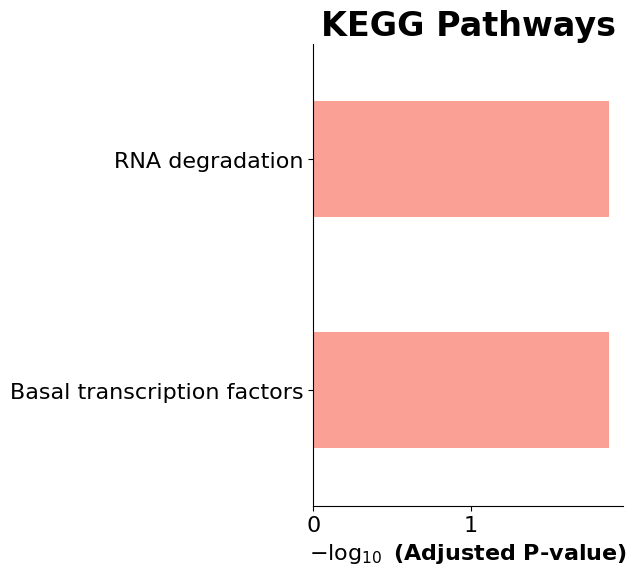

In [ ]:
# Graph if desired

gp.barplot(enr_wp.res2d, title='WikiPathways', top_term=10)
gp.barplot(enr_go.res2d, title='GO Biological Process', top_term=10)
gp.barplot(enr_kegg.res2d, title='KEGG Pathways', top_term=10)
gp.barplot(enr_goc.res2d, title='GO Cellular Componenet', top_term=10)



#### Genes that extend their poly(A) tails and are up regulated in hypoxia

In [ ]:
sig = ((merged['BH_adjusted_p_value'] <= 0.05) & (merged['delta_pT_H18WT_vs_N6WT'] > 5) & (merged['padjBulk'] <= 0.05) & (merged['log2FoldChangeBulk'] > 0.5))
genes_down = merged[sig]
genes_down

,Unnamed: 0,Gene,Avg_N6WT_Adjusted_pt_length,Avg_H18WT_Adjusted_pt_length,p_value,n_N6WT,n_H18WT,BH_adjusted_p_value,log2FC_H18WT_vs_N6WT,delta_pT_H18WT_vs_N6WT,baseMeanBulk,log2FoldChangeBulk,padjBulk
340,340,CABZ01045617.1,12.548535,19.997334,1.569061e-30,5854,6189,3.199780e-29,0.672289,7.448799,546.570562,1.186252,1.590615e-03
662,662,spata6l,84.337500,195.342315,3.259097e-15,90,501,3.418365e-14,1.211758,111.004815,887.506791,3.623596,2.166285e-12
728,728,aldoaa,78.700851,95.231941,7.372899e-14,969,2298,7.033078e-13,0.275066,16.531089,1885.497711,1.709900,1.371494e-07
838,838,hspa5,53.382009,143.951547,6.413574e-12,107,307,5.315852e-11,1.431158,90.569538,1446.946176,1.279795,1.943739e-07
890,890,rpl18,88.053346,98.839922,2.809640e-11,1584,3339,2.190398e-10,0.166716,10.786576,1238.153297,0.639824,7.877760e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3540,3540,adi1,60.015625,69.169079,1.791658e-02,88,190,3.518551e-02,0.204789,9.153454,191.124705,1.061622,1.409842e-07
3570,3570,cecr2,106.751656,130.495603,1.952048e-02,151,199,3.801327e-02,0.289743,23.743947,643.506339,0.599984,3.367098e-03
3640,3640,nhlrc2,57.456522,97.367188,2.225774e-02,23,64,4.251038e-02,0.760965,39.910666,96.002513,1.140349,4.589528e-13
3693,3693,PAXBP1,100.012821,233.722222,2.494496e-02,39,45,4.693604e-02,1.224610,133.709402,259.960530,0.635887,6.523099e-05


In [ ]:

genes_down = genes_down['Gene'].to_list()

In [ ]:
genes_down

['CABZ01045617.1',
 'spata6l',
 'aldoaa',
 'hspa5',
 'rpl18',
 'kansl2',
 'nkain4',
 'pgm1',
 'p4ha1b',
 'tent5ba',
 'rps27.1',
 'ppdpfb',
 'ube2e3',
 'abat',
 'rimkla',
 'eno1a',
 'rpl32',
 'histh1l',
 'rps26',
 'eef1g',
 'rps3a',
 'rpl15',
 'hsp70.3',
 'pgam1a',
 'rn7sk',
 'rps18',
 'nsmce2',
 'btg3',
 'nme3',
 'tmem63ba',
 'zgc:110425',
 'caly',
 'znf395a',
 'rpl9',
 'rpl10a',
 'rpl30',
 'foxk1',
 'mt2',
 'atp5po',
 'fbxl5',
 'tex2',
 'syngr2a',
 'tpi1b',
 'tubb4b',
 'cpne1',
 'hprt1',
 'prelid1a',
 'abhd6a',
 'fpgs',
 'rpl7',
 'ptmaa',
 'washc3',
 'ror2',
 'si:ch73-352p4.5',
 'rps16',
 'fbxw7',
 'ftr67',
 'scamp4',
 'si:ch211-207i20.3',
 'anxa11a',
 'hnf1ba',
 'adi1',
 'cecr2',
 'nhlrc2',
 'PAXBP1',
 'sfxn1']

In [ ]:
len(genes_down)

66

In [ ]:

# WikiPathways
enr_wp = gp.enrichr(
    gene_list=genes_down,
    gene_sets=['WikiPathways_2018'],
    organism='danio rerio',
    outdir='enrichr_wikipathways',
    cutoff=1
)

# GO Biological Process
enr_go = gp.enrichr(
    gene_list=genes_down,
    gene_sets=['GO_Biological_Process_2018'],
    organism='danio rerio',
    outdir='enrichr_go',
    cutoff=1
)

# KEGG
enr_kegg = gp.enrichr(
    gene_list=genes_down,
    gene_sets=['KEGG_2019'],
    organism='danio rerio',
    outdir='enrichr_kegg',
    cutoff=1
)


# GO Biological Process
enr_goc = gp.enrichr(
    gene_list=genes_down,
    gene_sets=['GO_Cellular_Component_2018'],
    organism='danio rerio',
    outdir='enrichr_go',
    cutoff=1
)


In [ ]:
results_wp = enr_wp.results
results_go = enr_go.results
results_kegg = enr_kegg.results
results_goc = enr_goc.results

In [ ]:
results_wp

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Z-score,Combined Score,Genes
0,WikiPathways_2018,Cytoplasmic Ribosomal Proteins_WP324,11/79,1.500000e-15,1.910000e-14,2.045550e-11,2.454670e-10,-1.554678,52.968443,rpl10a;rpl30;rps16;rps26;rpl32;rps18;rpl15;rps...
1,WikiPathways_2018,Glycolysis and Gluconeogenesis_WP1356,3/47,5.016959e-04,3.010175e-03,8.296097e-03,4.977658e-02,-1.935295,14.703437,eno1a;pgam1a;tpi1b
2,WikiPathways_2018,CRD motif and sFRPs influence on Wnt signaling...,1/10,3.252145e-02,1.300858e-01,9.103207e-02,3.641283e-01,-3.126630,10.711383,ror2
3,WikiPathways_2018,Apoptosis Modulation by HSP70_WP1392,1/15,4.838929e-02,1.451679e-01,1.297553e-01,3.892658e-01,-2.486176,7.529327,hsp70.3
4,WikiPathways_2018,Glycogen Metabolism_WP1388,1/28,8.845601e-02,2.008931e-01,2.232356e-01,5.000477e-01,-1.957117,4.746499,pgm1
5,WikiPathways_2018,Selenium metabolism Selenoproteins_WP1358,1/32,1.004466e-01,2.008931e-01,2.500238e-01,5.000477e-01,-1.643237,3.776370,rpl30
6,WikiPathways_2018,Exercise-induced Circadian Regulation_WP562,1/46,1.412029e-01,2.329703e-01,3.370369e-01,5.338353e-01,-1.535959,3.006727,tubb4b
7,WikiPathways_2018,Oxidative phosphorylation_WP1335,1/51,1.553135e-01,2.329703e-01,3.657198e-01,5.338353e-01,-1.389494,2.587667,atp5po
8,WikiPathways_2018,BMP signaling pathway_WP211,1/66,1.962894e-01,2.355473e-01,4.448627e-01,5.338353e-01,-1.484280,2.416653,rpl15
9,WikiPathways_2018,Delta-Notch Signaling Pathway_WP1382,1/65,1.936197e-01,2.355473e-01,4.398928e-01,5.338353e-01,-1.214505,1.994047,fbxw7


In [ ]:
results_kegg

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Z-score,Combined Score,Genes
0,KEGG_2019,"Alanine, aspartate and glutamate metabolism",2/41,8.094999e-03,5.258703e-02,2.408768e-02,1.559101e-01,-61.227312,294.901888,abat;rimkla
1,KEGG_2019,Ribosome,12/134,1.790000e-14,5.559000e-13,8.316200e-12,2.578040e-10,-8.674952,274.579799,rpl10a;rpl30;rps16;rps26;rpl32;rps18;rpl15;rps...
2,KEGG_2019,Butanoate metabolism,1/24,7.630809e-02,2.093103e-01,1.320273e-01,3.764451e-01,-71.687912,184.451298,abat
3,KEGG_2019,"Glycine, serine and threonine metabolism",1/44,1.354939e-01,2.333506e-01,2.253238e-01,4.001893e-01,-87.446110,174.789776,pgam1a
4,KEGG_2019,Galactose metabolism,1/33,1.034198e-01,2.093103e-01,1.752858e-01,3.764451e-01,-63.819187,144.803080,pgm1
5,KEGG_2019,Fructose and mannose metabolism,2/42,8.481779e-03,5.258703e-02,2.514680e-02,1.559101e-01,-29.812828,142.202274,aldoaa;tpi1b
6,KEGG_2019,RNA degradation,2/86,3.282069e-02,1.271802e-01,8.737805e-02,3.385899e-01,-38.761892,132.437607,btg3;eno1a
7,KEGG_2019,Starch and sucrose metabolism,1/34,1.063835e-01,2.093103e-01,1.799612e-01,3.764451e-01,-58.886533,131.947363,pgm1
8,KEGG_2019,Amino sugar and nucleotide sugar metabolism,1/57,1.719450e-01,2.464542e-01,2.806704e-01,4.001893e-01,-57.836970,101.826633,pgm1
9,KEGG_2019,Arginine and proline metabolism,1/61,1.828531e-01,2.464542e-01,2.969147e-01,4.001893e-01,-49.543952,84.178740,p4ha1b


In [ ]:
results_go

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Z-score,Combined Score,Genes
0,GO_Biological_Process_2018,cytoplasmic translation (GO:0002181),3/33,0.000174,0.016226,0.000235,0.021824,-2.315085,20.034197,rpl15;rpl7;rpl9
1,GO_Biological_Process_2018,L-methionine salvage from methylthioadenosine ...,1/6,0.019640,0.132359,0.023491,0.144722,-4.926905,19.363707,adi1
2,GO_Biological_Process_2018,positive regulation of cell migration involved...,1/6,0.019640,0.132359,0.023491,0.144722,-4.608775,18.113393,mt2
3,GO_Biological_Process_2018,histone H4-K5 acetylation (GO:0043981),1/6,0.019640,0.132359,0.023491,0.144722,-4.603329,18.091989,kansl2
4,GO_Biological_Process_2018,regulation of sodium ion transport (GO:0002028),1/6,0.019640,0.132359,0.023491,0.144722,-4.598981,18.074900,nkain4
...,...,...,...,...,...,...,...,...,...,...
181,GO_Biological_Process_2018,negative regulation of programmed cell death (...,1/258,0.576137,0.598667,0.589819,0.612884,-0.690029,0.380489,ror2
182,GO_Biological_Process_2018,negative regulation of apoptotic process (GO:0...,1/277,0.602277,0.615514,0.616144,0.629686,-0.729077,0.369670,ror2
183,GO_Biological_Process_2018,"positive regulation of transcription, DNA-temp...",1/403,0.739640,0.747680,0.753595,0.761786,-0.716607,0.216122,hnf1ba
184,GO_Biological_Process_2018,"regulation of transcription, DNA-templated (GO...",1/665,0.893062,0.897890,0.903870,0.908756,-0.713662,0.080714,hnf1ba


In [ ]:
results_goc

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Z-score,Combined Score,Genes
0,GO_Cellular_Component_2018,cytosolic ribosome (GO:0022626),9/92,1.844360e-11,4.795354e-10,2.050593e-10,5.331544e-09,-2.096666,51.821819,rpl10a;rpl30;rps16;rps26;rpl32;rpl15;rpl7;rpl9...
1,GO_Cellular_Component_2018,large ribosomal subunit (GO:0015934),7/54,4.814357e-10,3.129332e-09,4.736427e-09,3.078677e-08,-1.799339,38.603475,rpl10a;rpl30;rpl32;rpl15;rpl7;rpl9;rpl18
2,GO_Cellular_Component_2018,cytosolic part (GO:0044445),9/112,1.107965e-10,1.440355e-09,1.052032e-09,1.367641e-08,-1.571910,36.033400,rpl10a;rpl30;rps16;rps26;rpl32;rpl15;rpl7;rpl9...
3,GO_Cellular_Component_2018,cytosolic large ribosomal subunit (GO:0022625),7/52,3.655698e-10,3.129332e-09,3.724836e-09,3.078677e-08,-1.446125,31.423664,rpl10a;rpl30;rpl32;rpl15;rpl7;rpl9;rpl18
4,GO_Cellular_Component_2018,small ribosomal subunit (GO:0015935),3/42,3.593992e-04,1.868876e-03,9.223581e-04,4.796262e-03,-1.555140,12.333939,rps16;rps26;rps18
5,GO_Cellular_Component_2018,trans-Golgi network membrane (GO:0032588),1/13,4.207315e-02,1.218028e-01,5.926705e-02,1.690462e-01,-3.406384,10.792603,scamp4
6,GO_Cellular_Component_2018,recycling endosome membrane (GO:0055038),1/13,4.207315e-02,1.218028e-01,5.926705e-02,1.690462e-01,-3.148906,9.976823,scamp4
7,GO_Cellular_Component_2018,cytosolic small ribosomal subunit (GO:0022627),2/37,6.630648e-03,2.873281e-02,1.222965e-02,5.299514e-02,-1.932833,9.695191,rps16;rps26
8,GO_Cellular_Component_2018,mitochondrial intermembrane space (GO:0005758),1/16,5.153196e-02,1.218028e-01,7.151956e-02,1.690462e-01,-2.772558,8.222169,prelid1a
9,GO_Cellular_Component_2018,mitochondrial envelope (GO:0005740),1/16,5.153196e-02,1.218028e-01,7.151956e-02,1.690462e-01,-2.551024,7.565196,prelid1a


<Axes: title={'center': 'GO Cellular Componenet'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

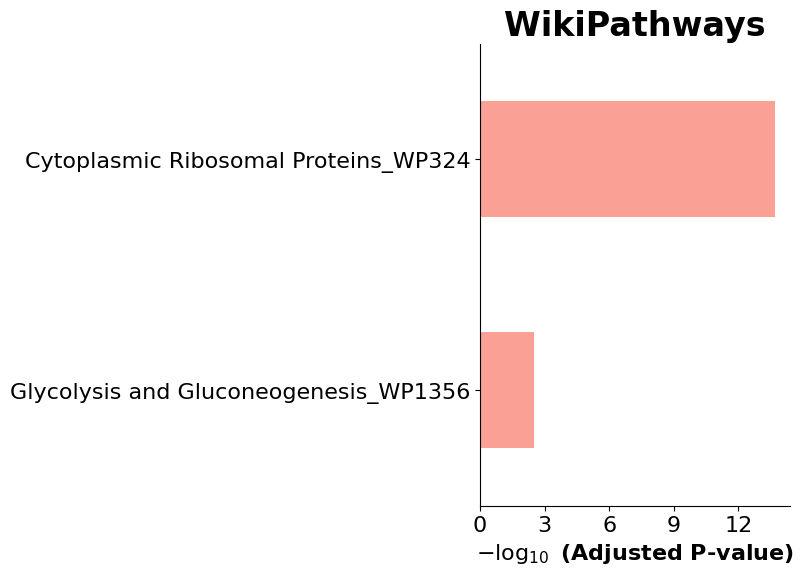

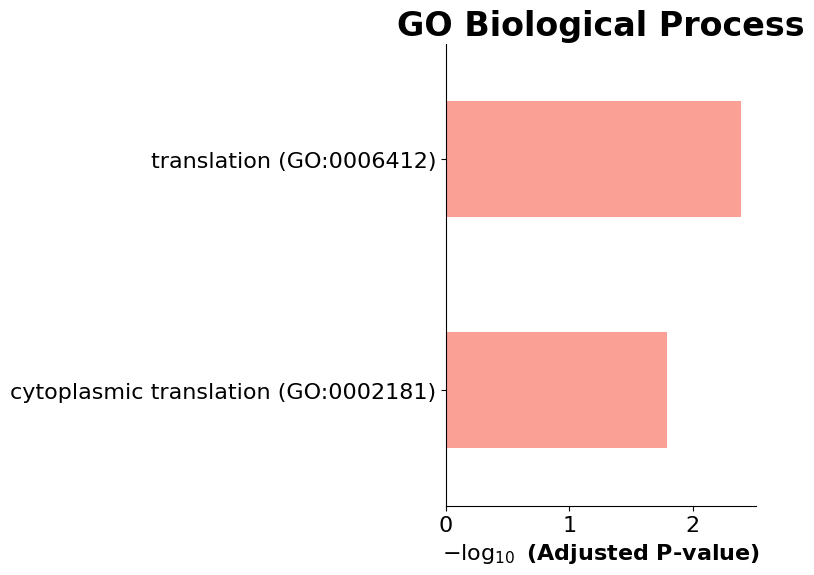

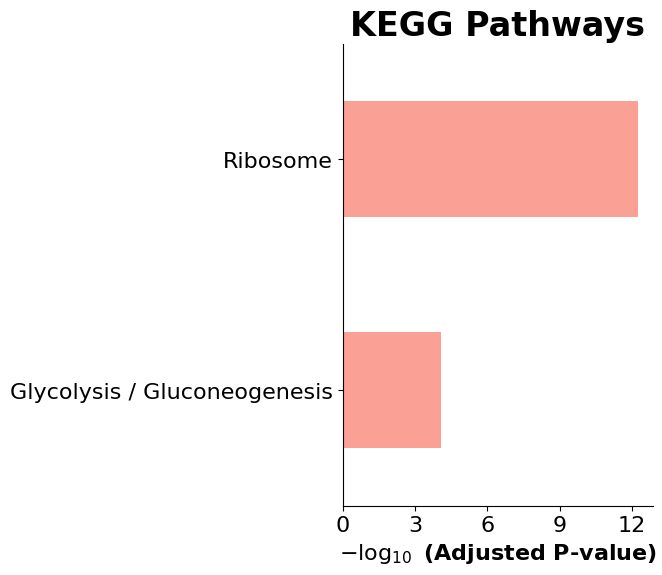

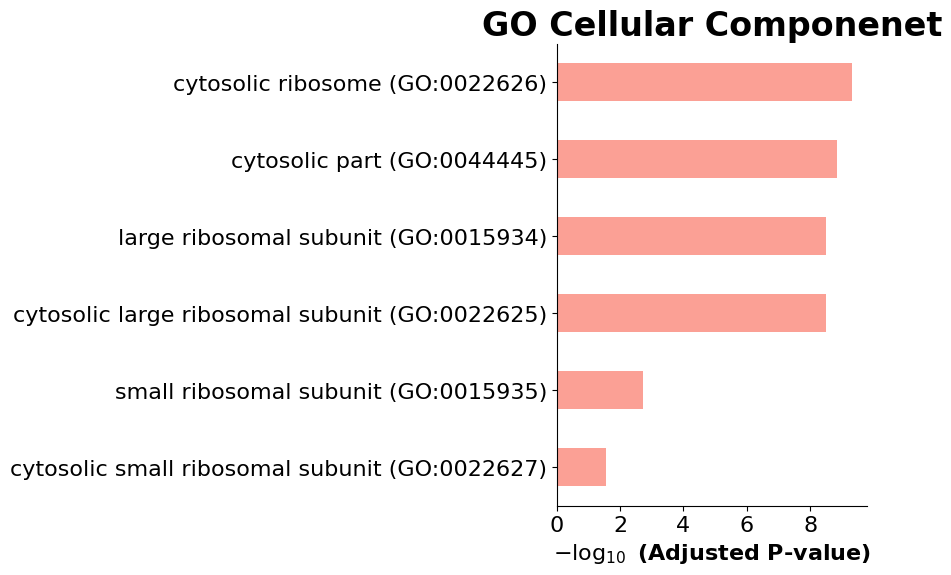

In [ ]:
gp.barplot(enr_wp.res2d, title='WikiPathways', top_term=10)
gp.barplot(enr_go.res2d, title='GO Biological Process', top_term=10)
gp.barplot(enr_kegg.res2d, title='KEGG Pathways', top_term=10)
gp.barplot(enr_goc.res2d, title='GO Cellular Componenet', top_term=10, cutoff=0.1)



### Poly(A) tail distribution

In [ ]:
#import pandas as pd
#import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

In [ ]:
df = pd.read_csv(data_path + '/CombinedR1R2_PolyAtable_annotated.csv', sep = '\t')
df

/tmp/ipykernel_41516/891892265.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Chris/Nano3pSeq/PostPolyTailor/CombinedR1R2_table_annotated.csv', sep = '\t')


,read_id,barcode,mapq,filter,pt_length,per_base,primer_end,pt_start,before_pt,pt_seq,...,exons,additional,comment,Gene,Group,Genotype,Method,Condition,Batch,Adjusted_pt_length
0,b08e7e33-7610-48f3-8ed9-f1a1293ed16f,SQK-NBD114-24_barcode07,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,39132-39280,gene_assignment=unique; PolyA=False; Classific...,NaN,XLOC_043623,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
1,1b514c91-eccd-4fe6-b857-1093e4061fcd,SQK-NBD114-24_barcode11,60,not_continuous,-0.2,3.9,100,101,GAGGCAGAGG,TTTTT,...,2235-3171,Classification=intergenic;,NaN,NaN,Hyp_rRNA_T42_2a,Tent5ba42,Hypoxia18,Hypoxia18,Batch1,1.750
2,8ab9bff2-43b2-4696-a238-b6c72f444674,SQK-NBD114-24_barcode07,18,no_primer,0.0,0.0,0,0,NaN,NaN,...,2866-3405,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
3,7f1adb2e-6d1c-483d-8bfc-037643264136,SQK-NBD114-24_barcode08,49,not_continuous,-0.2,2.6,144,149,CAGAGTCTGA,TTTT,...,2877-3141,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_2a,Wildtype,Hypoxia18,Hypoxia18,Batch1,1.750
4,4dd554ec-22ab-4fc3-84d9-0ed13e4c9fa3,SQK-NBD114-24_barcode07,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,3095-3559,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27307111,eddc7366-6312-47a7-b918-5beedcc5abe7,SQK-NBD114-24_barcode13,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,16399-16596,gene_assignment=inconsistent_non_intronic; Pol...,NaN,NaN,Hyp_rRNA_WT_1,Wildtype,Hypoxia18,Hypoxia18,Batch2,2.000
27307112,cdbb438e-243c-4122-a166-959b0145e540,SQK-NBD114-24_barcode05,60,OK,10.8,3.5,104,104,CAGAGCAGAG,TTTTTTTTTTTTTTTTTATT,...,16400-16515,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Norm_rRNA_T42_2,Tent5ba42,Normoxia6hpf,Normoxia6hpf,Batch2,15.500
27307113,a25e139b-ff92-4766-8e3b-86a37959dea8,SQK-NBD114-24_barcode16,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,16402-16560,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Hyp_rRNA_T42_1,Tent5ba42,Hypoxia18,Hypoxia18,Batch2,2.000
27307114,4d397346-f635-44df-b346-b6588a666674,SQK-NBD114-24_barcode04,60,OK,12.9,2.9,103,103,CAGAGCAGAG,TTATTTTTTTTTTTTTT,...,16403-16522,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Norm_rRNA_T42_1,Tent5ba42,Normoxia6hpf,Normoxia6hpf,Batch2,18.125


In [ ]:
df1 = df[df["filter"] == 'OK']

df2 = df1[df1["Gene"].notna()]

df2 = df2.loc[df2['Group'].isin((
    "Norm_rRNA_WT_1", "Norm_rRNA_WT_2", "Norm_rRNA_WT_3",
    "Hyp_rRNA_WT_1a", "Hyp_rRNA_WT_2a", "Hyp_rRNA_WT_3a",
    "Hyp_rRNA_WT_1", "Hyp_rRNA_WT_2", "Hyp_rRNA_WT_3",
))]

df2



FILTERING STATISTICS
Original number of reads: 3658219
Filtered number of reads: 3215981
Original number of unique genes: 21629
Filtered number of unique genes: 5748


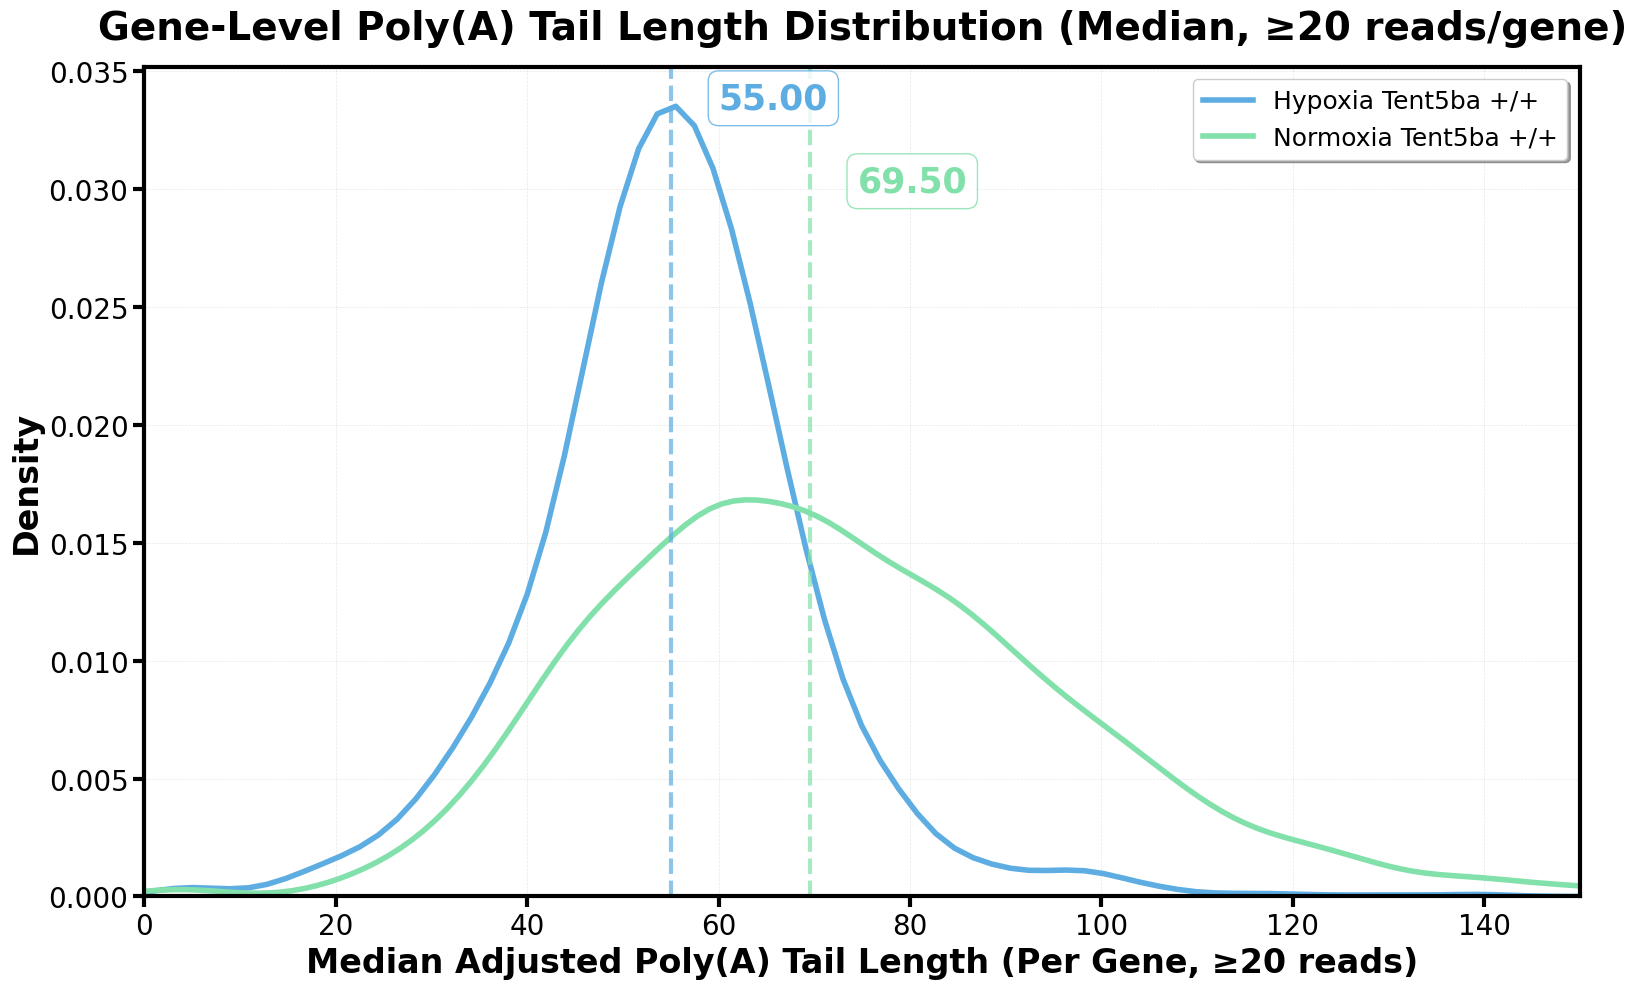


PAIRWISE MANN-WHITNEY U TESTS (BH-CORRECTED)
       Comparison       P-value  BH-corrected P-value  Significant (α=0.05)
Hyp_WT vs Norm_WT 4.274782e-307         4.274782e-307                  True

GENE COUNTS PER GROUP TYPE (≥20 reads)
Hyp_WT: 5281 genes
Hyp_T42: 0 genes
Norm_WT: 4712 genes
Norm_T42: 0 genes

OVERALL MEDIANS (ACROSS GENES)
Hypoxia Tent5ba +/+: 55.00
Normoxia Tent5ba +/+: 69.50

GENE-LEVEL STATISTICS
             count       mean        std     min     25%   50%     75%  \
Group_Type                                                               
Hyp_WT      5281.0  55.690222  18.126226  1.2500  47.375  55.0  62.875   
Norm_WT     4712.0  72.282550  25.201340  0.8125  54.625  69.5  87.000   

                 max  
Group_Type            
Hyp_WT      368.0000  
Norm_WT     220.5625  

SAMPLE OF GENE-LEVEL DATA
          Gene Group_Type  Median_Adjusted_pt_length
0          AK6     Hyp_WT                    44.3750
1          AK6    Norm_WT                    48.9375
2  

In [ ]:

# Define all group columns
all_cols = [

    "Norm_rRNA_WT_1", "Norm_rRNA_WT_2", "Norm_rRNA_WT_3",
   "Hyp_rRNA_WT_1a", "Hyp_rRNA_WT_2a", "Hyp_rRNA_WT_3a",
    "Hyp_rRNA_WT_1", "Hyp_rRNA_WT_2", "Hyp_rRNA_WT_3",
]

# Extract condition and genotype from Group column
def parse_group(group_name):
    if 'Hyp' in group_name and 'WT' in group_name:
        return 'Hyp', 'WT', 'Hyp_WT'
    elif 'Hyp' in group_name and 'T42' in group_name:
        return 'Hyp', 'T42', 'Hyp_T42'
    elif 'Norm' in group_name and 'WT' in group_name:
        return 'Norm', 'WT', 'Norm_WT'
    elif 'Norm' in group_name and 'T42' in group_name:
        return 'Norm', 'T42', 'Norm_T42'
    return None, None, None

df2['Condition'], df2['Genotype'], df2['Group_Type'] = zip(*df2['Group'].apply(parse_group))

# Filter genes: only keep genes with at least 20 reads per group
def filter_genes_by_read_count(df, min_reads=20):
    """Filter to only include genes with at least min_reads in each group"""
    gene_counts = df.groupby(['Gene', 'Group']).size().reset_index(name='read_count')
    genes_passing_filter = gene_counts[gene_counts['read_count'] >= min_reads][['Gene', 'Group']]

    # Merge back to keep only the passing combinations
    df_filtered = df.merge(genes_passing_filter, on=['Gene', 'Group'], how='inner')
    return df_filtered

df2_filtered = filter_genes_by_read_count(df2, min_reads=20)

print(f"\n{'='*80}")
print(f"FILTERING STATISTICS")
print(f"{'='*80}")
print(f"Original number of reads: {len(df2)}")
print(f"Filtered number of reads: {len(df2_filtered)}")
print(f"Original number of unique genes: {len(df2['Gene'].unique())}")
print(f"Filtered number of unique genes: {len(df2_filtered['Gene'].unique())}")

# Calculate gene-level medians for each individual replicate (Group)
gene_medians_by_replicate = df2_filtered.groupby(['Gene', 'Group'])['Adjusted_pt_length'].median().reset_index()
gene_medians_by_replicate.columns = ['Gene', 'Group', 'Median_Adjusted_pt_length']
gene_medians_by_replicate['Condition'], gene_medians_by_replicate['Genotype'], gene_medians_by_replicate['Group_Type'] = \
    zip(*gene_medians_by_replicate['Group'].apply(parse_group))

# Calculate gene-level medians for overall group types (averaged across replicates)
gene_medians = df2_filtered.groupby(['Gene', 'Group_Type'])['Adjusted_pt_length'].median().reset_index()
gene_medians.columns = ['Gene', 'Group_Type', 'Median_Adjusted_pt_length']

# Define colors
colors = {
    'Hyp_WT': '#5DADE2',      # Light blue
    'Hyp_T42': '#1A5490',     # Dark blue
    'Norm_WT': '#82E0AA',     # Light green
    'Norm_T42': '#196F3D'     # Dark green
}

# Lighter colors for individual replicates
light_colors = {
    'Hyp_WT': '#AED6F1',      # Very light blue
    'Hyp_T42': '#2E6BA8',     # Medium blue
    'Norm_WT': '#ABEBC6',     # Very light green
    'Norm_T42': '#28B463'     # Medium green
}

# Perform pairwise Mann-Whitney tests on gene-level medians
group_types = ['Hyp_WT', 'Hyp_T42', 'Norm_WT', 'Norm_T42']
pairwise_comparisons = list(combinations(group_types, 2))

pvalues = []
comparisons = []

for group1, group2 in pairwise_comparisons:
    group1_medians = gene_medians.loc[gene_medians['Group_Type'] == group1, 'Median_Adjusted_pt_length'].dropna()
    group2_medians = gene_medians.loc[gene_medians['Group_Type'] == group2, 'Median_Adjusted_pt_length'].dropna()

    if len(group1_medians) > 0 and len(group2_medians) > 0:
        u_stat, p_val = mannwhitneyu(group1_medians, group2_medians, alternative="two-sided")
        pvalues.append(p_val)
        comparisons.append(f"{group1} vs {group2}")

# Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(pvalues, alpha=0.05, method='fdr_bh')

# Create results dataframe
results_df = pd.DataFrame({
    'Comparison': comparisons,
    'P-value': pvalues,
    'BH-corrected P-value': pvals_corrected,
    'Significant (α=0.05)': reject
})

# Create the plot
fig, ax = plt.subplots(figsize=(16, 10))



# Plot main group distributions with thick lines
labels = {
    'Hyp_WT': 'Hypoxia Tent5ba +/+',
    'Hyp_T42': 'Hypoxia Tent5ba-42/-42',
    'Norm_WT': 'Normoxia Tent5ba +/+',
    'Norm_T42': 'Normoxia Tent5ba-42/-42'
}

medians = {}
for group_type in group_types:
    group_data = gene_medians[gene_medians['Group_Type'] == group_type]['Median_Adjusted_pt_length'].dropna()
    if len(group_data) > 0:
        medians[group_type] = group_data.median()
        sns.kdeplot(data=group_data, color=colors[group_type], fill=False,
                   alpha=1, linewidth=4, label=labels[group_type], ax=ax)

# Plot median lines
y_pos = ax.get_ylim()[1]
text_positions = [0.95, 0.90, 0.85, 0.80]
for i, group_type in enumerate(group_types):
    if group_type in medians:
        median_val = medians[group_type]
        ax.axvline(median_val, linestyle="--", color=colors[group_type],
                  linewidth=3, alpha=0.7)
        ax.text(median_val + 5, y_pos * text_positions[i], f'{median_val:.2f}',
               fontsize=25, color=colors[group_type], weight='bold',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8,
                        edgecolor=colors[group_type]))

ax.set_xlabel("Median Adjusted Poly(A) Tail Length (Per Gene, ≥20 reads)", fontsize=24, weight='bold')
ax.set_ylabel("Density", fontsize=24, weight='bold')
ax.set_title("Gene-Level Poly(A) Tail Length Distribution (Median, ≥20 reads/gene)", fontsize=28, weight='bold', pad=20)
ax.legend(fontsize=18, frameon=True, shadow=True, loc='upper right')

ax.tick_params(labelsize=20, width=3, length=8)
for spine in ax.spines.values():
    spine.set_linewidth(3)

ax.set_xlim(0, 150)  # Clip x-axis at 200
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(data_path + '/Plots/N6WTvsH18WT_Poly(A)Distrb_gene_level_median.png',
            dpi=600, bbox_inches='tight')
plt.show()

# Print statistics
print("\n" + "="*80)
print("PAIRWISE MANN-WHITNEY U TESTS (BH-CORRECTED)")
print("="*80)
print(results_df.to_string(index=False))

print("\n" + "="*80)
print("GENE COUNTS PER GROUP TYPE (≥20 reads)")
print("="*80)
for group_type in group_types:
    n = len(gene_medians[gene_medians['Group_Type'] == group_type])
    print(f"{group_type}: {n} genes")

print("\n" + "="*80)
print("OVERALL MEDIANS (ACROSS GENES)")
print("="*80)
for group_type in group_types:
    if group_type in medians:
        print(f"{labels[group_type]}: {medians[group_type]:.2f}")

print("\n" + "="*80)
print("GENE-LEVEL STATISTICS")
print("="*80)
print(gene_medians.groupby('Group_Type')['Median_Adjusted_pt_length'].describe())

print("\n" + "="*80)
print("SAMPLE OF GENE-LEVEL DATA")
print("="*80)
print(gene_medians.head(20))

print("\n" + "="*80)
print("READ COUNT DISTRIBUTION (genes with ≥20 reads)")
print("="*80)
read_counts = df2_filtered.groupby(['Gene', 'Group']).size().reset_index(name='read_count')
print(read_counts['read_count'].describe())

## Normoxia 6 hpf *tent5ba*+/+ vs Normoxia 6 hpf *tent5ba*-42/-42

### Poly(A) tail distribution

In [ ]:
#import pandas as pd
#import numpy as np
#from scipy.stats import mannwhitneyu
#from statsmodels.stats.multitest import multipletests
#import matplotlib.pyplot as plt
#import seaborn as sns
#from itertools import combinations

In [ ]:
# re import if desired
#df = pd.read_csv('/content/drive/MyDrive/Chris/Nano3pSeq/PostPolyTailor/CombinedR1R2_table_annotated.csv', sep = '\t')
#df

/tmp/ipykernel_41516/891892265.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Chris/Nano3pSeq/PostPolyTailor/CombinedR1R2_table_annotated.csv', sep = '\t')


,read_id,barcode,mapq,filter,pt_length,per_base,primer_end,pt_start,before_pt,pt_seq,...,exons,additional,comment,Gene,Group,Genotype,Method,Condition,Batch,Adjusted_pt_length
0,b08e7e33-7610-48f3-8ed9-f1a1293ed16f,SQK-NBD114-24_barcode07,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,39132-39280,gene_assignment=unique; PolyA=False; Classific...,NaN,XLOC_043623,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
1,1b514c91-eccd-4fe6-b857-1093e4061fcd,SQK-NBD114-24_barcode11,60,not_continuous,-0.2,3.9,100,101,GAGGCAGAGG,TTTTT,...,2235-3171,Classification=intergenic;,NaN,NaN,Hyp_rRNA_T42_2a,Tent5ba42,Hypoxia18,Hypoxia18,Batch1,1.750
2,8ab9bff2-43b2-4696-a238-b6c72f444674,SQK-NBD114-24_barcode07,18,no_primer,0.0,0.0,0,0,NaN,NaN,...,2866-3405,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
3,7f1adb2e-6d1c-483d-8bfc-037643264136,SQK-NBD114-24_barcode08,49,not_continuous,-0.2,2.6,144,149,CAGAGTCTGA,TTTT,...,2877-3141,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_2a,Wildtype,Hypoxia18,Hypoxia18,Batch1,1.750
4,4dd554ec-22ab-4fc3-84d9-0ed13e4c9fa3,SQK-NBD114-24_barcode07,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,3095-3559,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27307111,eddc7366-6312-47a7-b918-5beedcc5abe7,SQK-NBD114-24_barcode13,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,16399-16596,gene_assignment=inconsistent_non_intronic; Pol...,NaN,NaN,Hyp_rRNA_WT_1,Wildtype,Hypoxia18,Hypoxia18,Batch2,2.000
27307112,cdbb438e-243c-4122-a166-959b0145e540,SQK-NBD114-24_barcode05,60,OK,10.8,3.5,104,104,CAGAGCAGAG,TTTTTTTTTTTTTTTTTATT,...,16400-16515,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Norm_rRNA_T42_2,Tent5ba42,Normoxia6hpf,Normoxia6hpf,Batch2,15.500
27307113,a25e139b-ff92-4766-8e3b-86a37959dea8,SQK-NBD114-24_barcode16,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,16402-16560,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Hyp_rRNA_T42_1,Tent5ba42,Hypoxia18,Hypoxia18,Batch2,2.000
27307114,4d397346-f635-44df-b346-b6588a666674,SQK-NBD114-24_barcode04,60,OK,12.9,2.9,103,103,CAGAGCAGAG,TTATTTTTTTTTTTTTT,...,16403-16522,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Norm_rRNA_T42_1,Tent5ba42,Normoxia6hpf,Normoxia6hpf,Batch2,18.125


In [ ]:
df1 = df[df["filter"] == 'OK']

df2 = df1[df1["Gene"].notna()]

df2 = df2.loc[df2['Group'].isin((
    "Norm_rRNA_WT_1",
    "Norm_rRNA_WT_2",
    "Norm_rRNA_WT_3",
    "Norm_rRNA_T42_1",
    "Norm_rRNA_T42_2",
    "Norm_rRNA_T42_3"
))]


FILTERING STATISTICS
Original number of reads: 3325667
Filtered number of reads: 2973698
Original number of unique genes: 21122
Filtered number of unique genes: 6404


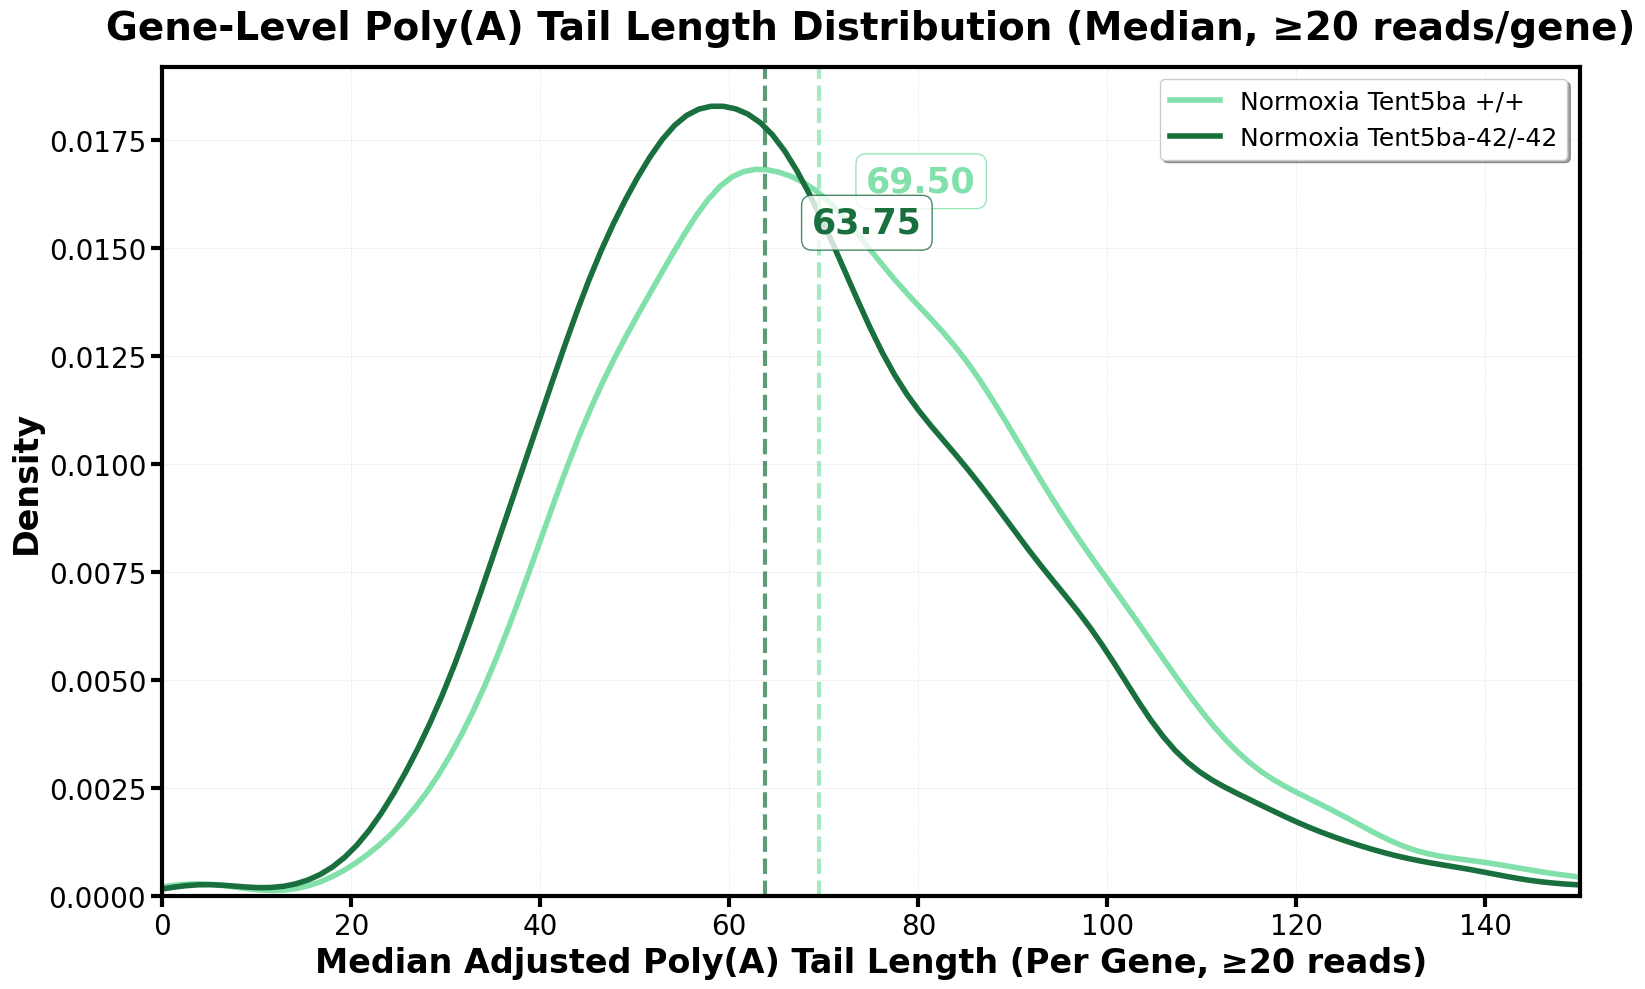


PAIRWISE MANN-WHITNEY U TESTS (BH-CORRECTED)
         Comparison      P-value  BH-corrected P-value  Significant (α=0.05)
Norm_WT vs Norm_T42 7.795245e-33          7.795245e-33                  True

GENE COUNTS PER GROUP TYPE (≥20 reads)
Hyp_WT: 0 genes
Hyp_T42: 0 genes
Norm_WT: 4712 genes
Norm_T42: 6326 genes

OVERALL MEDIANS (ACROSS GENES)
Normoxia Tent5ba +/+: 69.50
Normoxia Tent5ba-42/-42: 63.75

GENE-LEVEL STATISTICS
             count       mean       std     min      25%    50%   75%  \
Group_Type                                                              
Norm_T42    6326.0  66.945769  24.36446  1.0000  49.8125  63.75  81.0   
Norm_WT     4712.0  72.282550  25.20134  0.8125  54.6250  69.50  87.0   

                 max  
Group_Type            
Norm_T42    232.7500  
Norm_WT     220.5625  

SAMPLE OF GENE-LEVEL DATA
          Gene Group_Type  Median_Adjusted_pt_length
0          AK6   Norm_T42                    45.4375
1          AK6    Norm_WT                    48.9375
2

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Define all group columns
all_cols = [

    "Norm_rRNA_WT_1", "Norm_rRNA_WT_2", "Norm_rRNA_WT_3",
    "Norm_rRNA_T42_1", "Norm_rRNA_T42_2", "Norm_rRNA_T42_3"
]

# Extract condition and genotype from Group column
def parse_group(group_name):
    if 'Hyp' in group_name and 'WT' in group_name:
        return 'Hyp', 'WT', 'Hyp_WT'
    elif 'Hyp' in group_name and 'T42' in group_name:
        return 'Hyp', 'T42', 'Hyp_T42'
    elif 'Norm' in group_name and 'WT' in group_name:
        return 'Norm', 'WT', 'Norm_WT'
    elif 'Norm' in group_name and 'T42' in group_name:
        return 'Norm', 'T42', 'Norm_T42'
    return None, None, None

df2['Condition'], df2['Genotype'], df2['Group_Type'] = zip(*df2['Group'].apply(parse_group))

# Filter genes: only keep genes with at least 20 reads per group
def filter_genes_by_read_count(df, min_reads=20):
    """Filter to only include genes with at least min_reads in each group"""
    gene_counts = df.groupby(['Gene', 'Group']).size().reset_index(name='read_count')
    genes_passing_filter = gene_counts[gene_counts['read_count'] >= min_reads][['Gene', 'Group']]

    # Merge back to keep only the passing combinations
    df_filtered = df.merge(genes_passing_filter, on=['Gene', 'Group'], how='inner')
    return df_filtered

df2_filtered = filter_genes_by_read_count(df2, min_reads=20)

print(f"\n{'='*80}")
print(f"FILTERING STATISTICS")
print(f"{'='*80}")
print(f"Original number of reads: {len(df2)}")
print(f"Filtered number of reads: {len(df2_filtered)}")
print(f"Original number of unique genes: {len(df2['Gene'].unique())}")
print(f"Filtered number of unique genes: {len(df2_filtered['Gene'].unique())}")

# Calculate gene-level medians for each individual replicate (Group)
gene_medians_by_replicate = df2_filtered.groupby(['Gene', 'Group'])['Adjusted_pt_length'].median().reset_index()
gene_medians_by_replicate.columns = ['Gene', 'Group', 'Median_Adjusted_pt_length']
gene_medians_by_replicate['Condition'], gene_medians_by_replicate['Genotype'], gene_medians_by_replicate['Group_Type'] = \
    zip(*gene_medians_by_replicate['Group'].apply(parse_group))

# Calculate gene-level medians for overall group types (averaged across replicates)
gene_medians = df2_filtered.groupby(['Gene', 'Group_Type'])['Adjusted_pt_length'].median().reset_index()
gene_medians.columns = ['Gene', 'Group_Type', 'Median_Adjusted_pt_length']

# Define colors
colors = {
    'Hyp_WT': '#5DADE2',      # Light blue
    'Hyp_T42': '#1A5490',     # Dark blue
    'Norm_WT': '#82E0AA',     # Light green
    'Norm_T42': '#196F3D'     # Dark green
}

# Lighter colors for individual replicates
light_colors = {
    'Hyp_WT': '#AED6F1',      # Very light blue
    'Hyp_T42': '#2E6BA8',     # Medium blue
    'Norm_WT': '#ABEBC6',     # Very light green
    'Norm_T42': '#28B463'     # Medium green
}

# Perform pairwise Mann-Whitney tests on gene-level medians
group_types = ['Hyp_WT', 'Hyp_T42', 'Norm_WT', 'Norm_T42']
pairwise_comparisons = list(combinations(group_types, 2))

pvalues = []
comparisons = []

for group1, group2 in pairwise_comparisons:
    group1_medians = gene_medians.loc[gene_medians['Group_Type'] == group1, 'Median_Adjusted_pt_length'].dropna()
    group2_medians = gene_medians.loc[gene_medians['Group_Type'] == group2, 'Median_Adjusted_pt_length'].dropna()

    if len(group1_medians) > 0 and len(group2_medians) > 0:
        u_stat, p_val = mannwhitneyu(group1_medians, group2_medians, alternative="two-sided")
        pvalues.append(p_val)
        comparisons.append(f"{group1} vs {group2}")

# Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(pvalues, alpha=0.05, method='fdr_bh')

# Create results dataframe
results_df = pd.DataFrame({
    'Comparison': comparisons,
    'P-value': pvalues,
    'BH-corrected P-value': pvals_corrected,
    'Significant (α=0.05)': reject
})

# Create the plot
fig, ax = plt.subplots(figsize=(16, 10))



# Plot main group distributions with thick lines
labels = {
    'Hyp_WT': 'Hypoxia Tent5ba +/+',
    'Hyp_T42': 'Hypoxia Tent5ba-42/-42',
    'Norm_WT': 'Normoxia Tent5ba +/+',
    'Norm_T42': 'Normoxia Tent5ba-42/-42'
}

medians = {}
for group_type in group_types:
    group_data = gene_medians[gene_medians['Group_Type'] == group_type]['Median_Adjusted_pt_length'].dropna()
    if len(group_data) > 0:
        medians[group_type] = group_data.median()
        sns.kdeplot(data=group_data, color=colors[group_type], fill=False,
                   alpha=1, linewidth=4, label=labels[group_type], ax=ax)

# Plot median lines
y_pos = ax.get_ylim()[1]
text_positions = [0.95, 0.90, 0.85, 0.80]
for i, group_type in enumerate(group_types):
    if group_type in medians:
        median_val = medians[group_type]
        ax.axvline(median_val, linestyle="--", color=colors[group_type],
                  linewidth=3, alpha=0.7)
        ax.text(median_val + 5, y_pos * text_positions[i], f'{median_val:.2f}',
               fontsize=25, color=colors[group_type], weight='bold',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8,
                        edgecolor=colors[group_type]))

ax.set_xlabel("Median Adjusted Poly(A) Tail Length (Per Gene, ≥20 reads)", fontsize=24, weight='bold')
ax.set_ylabel("Density", fontsize=24, weight='bold')
ax.set_title("Gene-Level Poly(A) Tail Length Distribution (Median, ≥20 reads/gene)", fontsize=28, weight='bold', pad=20)
ax.legend(fontsize=18, frameon=True, shadow=True, loc='upper right')

ax.tick_params(labelsize=20, width=3, length=8)
for spine in ax.spines.values():
    spine.set_linewidth(3)

ax.set_xlim(0, 150)  # Clip x-axis at 200
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(data_path + '/Plots/N6WTvsn6T42_Poly(A)Distrb_gene_level_median.png',
            dpi=600, bbox_inches='tight')
plt.show()

# Print statistics
print("\n" + "="*80)
print("PAIRWISE MANN-WHITNEY U TESTS (BH-CORRECTED)")
print("="*80)
print(results_df.to_string(index=False))

print("\n" + "="*80)
print("GENE COUNTS PER GROUP TYPE (≥20 reads)")
print("="*80)
for group_type in group_types:
    n = len(gene_medians[gene_medians['Group_Type'] == group_type])
    print(f"{group_type}: {n} genes")

print("\n" + "="*80)
print("OVERALL MEDIANS (ACROSS GENES)")
print("="*80)
for group_type in group_types:
    if group_type in medians:
        print(f"{labels[group_type]}: {medians[group_type]:.2f}")

print("\n" + "="*80)
print("GENE-LEVEL STATISTICS")
print("="*80)
print(gene_medians.groupby('Group_Type')['Median_Adjusted_pt_length'].describe())

print("\n" + "="*80)
print("SAMPLE OF GENE-LEVEL DATA")
print("="*80)
print(gene_medians.head(20))

print("\n" + "="*80)
print("READ COUNT DISTRIBUTION (genes with ≥20 reads)")
print("="*80)
read_counts = df2_filtered.groupby(['Gene', 'Group']).size().reset_index(name='read_count')
print(read_counts['read_count'].describe())

### Differential polyadenylation vs differential gene expression

In [ ]:
# import differential polyadenylation results from previous notebooks

result_df5 = pd.read_csv(data_path + "/N6WTvsN6T42_Stats/ByCondition_20reads.csv")

In [ ]:
result_df5

,Gene,Avg_N6WT_Adjusted_pt_length,Avg_N6T42_Adjusted_pt_length,p_value,n_N6WT,n_N6T42,BH_adjusted_p_value,log2FC_N6T42_vs_N6WT,delta_pT_N6T42_vs_N6WT
0,ddx39ab,87.698935,99.299204,2.787009e-39,3356,3643,1.979891e-35,0.179223,11.600269
1,snrpd3,61.106285,71.326138,1.555960e-37,1790,2965,5.526769e-34,0.223110,10.219853
2,hspa8,78.715011,85.259457,2.879831e-31,6620,9371,6.819439e-28,0.115221,6.544446
3,actb2,84.201923,90.699911,4.049413e-29,5642,9246,5.753405e-26,0.107248,6.497988
4,rpl12,84.452174,96.953488,3.696636e-29,2530,1978,5.753405e-26,0.199158,12.501314
...,...,...,...,...,...,...,...,...,...
7099,XLOC_030237,79.078125,79.454545,1.000000e+00,32,44,1.000000e+00,0.006851,0.376420
7100,aqr,101.837687,93.250000,9.983005e-01,67,71,1.000000e+00,-0.127096,-8.587687
7101,XLOC_043201,78.877500,78.719008,1.000000e+00,100,121,1.000000e+00,-0.002902,-0.158492
7102,CR450780.2,89.901989,87.109589,9.972906e-01,88,73,1.000000e+00,-0.045521,-2.792400


In [ ]:
# import differential gene expression results from nano3pseq deseq2 output

bulk = pd.read_csv(data_path + '/Nano3pSeqNormoxia_6hpf_T42VsNormoxia_6hpf_WTDGEGenesAll.csv')
bulk = bulk.rename(columns = {"genes":"Gene"})
bulk1 = bulk.drop(['lfcSE', 'stat', 'pvalue'], axis = 1)
bulk1

,Gene,baseMean,log2FoldChange,padj
0,ABCD2_1_of_many,0.741449,0.279103,NaN
1,ACOT12,2.512188,0.096351,NaN
2,ACSF3,0.766287,1.828605,NaN
3,ACVR1C,0.502768,2.251928,NaN
4,ADAM12_1_of_many,0.176918,-1.247382,NaN
...,...,...,...,...
23792,zwilch,18.673202,0.472740,0.878680
23793,zyg11,4.037513,-0.148969,NaN
23794,zyx,12.320581,-1.107818,0.485993
23795,zzef1,5.930465,-0.674422,NaN


In [ ]:
# Merge on Gene
merged = merged.merge(bulk1, on="Gene", how="left")

# Rename columns
merged = merged.rename(columns={
    "baseMean":"baseMeanBulk",
    "log2FoldChange":"log2FoldChangeBulk",
    "padj":"padjBulk"
})

# Now merged contains both tables combined
merged.head()

,Gene,Avg_N6WT_Adjusted_pt_length,Avg_N6T42_Adjusted_pt_length,p_value,n_N6WT,n_N6T42,BH_adjusted_p_value,log2FC_N6T42_vs_N6WT,delta_pT_N6T42_vs_N6WT,Tent5ba count,Wildtype count,baseMeanBulk,log2FoldChangeBulk,padjBulk
0,ddx39ab,87.698935,99.299204,2.787009e-39,3356,3643,1.979891e-35,0.179223,11.600269,3643.0,3356.0,1065.158795,-0.327808,3.187401e-02
1,snrpd3,61.106285,71.326138,1.555960e-37,1790,2965,5.526769e-34,0.223110,10.219853,2965.0,1790.0,702.836623,0.292256,1.946121e-01
2,hspa8,78.715011,85.259457,2.879831e-31,6620,9371,6.819439e-28,0.115221,6.544446,9371.0,6620.0,2366.873985,0.037967,9.702932e-01
3,actb2,84.201923,90.699911,4.049413e-29,5642,9246,5.753405e-26,0.107248,6.497988,9246.0,5642.0,2183.876563,0.256372,1.128826e-01
4,rpl12,84.452174,96.953488,3.696636e-29,2530,1978,5.753405e-26,0.199158,12.501314,1978.0,2530.0,717.256938,-0.825559,3.725670e-08


In [ ]:
merged['Total reads'] = (merged['Tent5ba count'] + merged['Wildtype count'])

In [ ]:
merged

,Gene,Avg_N6WT_Adjusted_pt_length,Avg_N6T42_Adjusted_pt_length,p_value,n_N6WT,n_N6T42,BH_adjusted_p_value,log2FC_N6T42_vs_N6WT,delta_pT_N6T42_vs_N6WT,Tent5ba count,Wildtype count,baseMeanBulk,log2FoldChangeBulk,padjBulk,Total reads
0,ddx39ab,87.698935,99.299204,2.787009e-39,3356,3643,1.979891e-35,0.179223,11.600269,3643.0,3356.0,1065.158795,-0.327808,3.187401e-02,6999.0
1,snrpd3,61.106285,71.326138,1.555960e-37,1790,2965,5.526769e-34,0.223110,10.219853,2965.0,1790.0,702.836623,0.292256,1.946121e-01,4755.0
2,hspa8,78.715011,85.259457,2.879831e-31,6620,9371,6.819439e-28,0.115221,6.544446,9371.0,6620.0,2366.873985,0.037967,9.702932e-01,15991.0
3,actb2,84.201923,90.699911,4.049413e-29,5642,9246,5.753405e-26,0.107248,6.497988,9246.0,5642.0,2183.876563,0.256372,1.128826e-01,14888.0
4,rpl12,84.452174,96.953488,3.696636e-29,2530,1978,5.753405e-26,0.199158,12.501314,1978.0,2530.0,717.256938,-0.825559,3.725670e-08,4508.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7099,XLOC_030237,79.078125,79.454545,1.000000e+00,32,44,1.000000e+00,0.006851,0.376420,44.0,32.0,11.734529,0.051833,9.946630e-01,76.0
7100,aqr,101.837687,93.250000,9.983005e-01,67,71,1.000000e+00,-0.127096,-8.587687,71.0,67.0,21.178140,-0.245441,9.570727e-01,138.0
7101,XLOC_043201,78.877500,78.719008,1.000000e+00,100,121,1.000000e+00,-0.002902,-0.158492,121.0,100.0,35.723308,-0.118632,9.756291e-01,221.0
7102,CR450780.2,89.901989,87.109589,9.972906e-01,88,73,1.000000e+00,-0.045521,-2.792400,73.0,88.0,23.237196,-0.755208,6.069945e-01,161.0


Total points: 51, Valid points: 51
Pearson r = 0.315, p = 2.418e-02


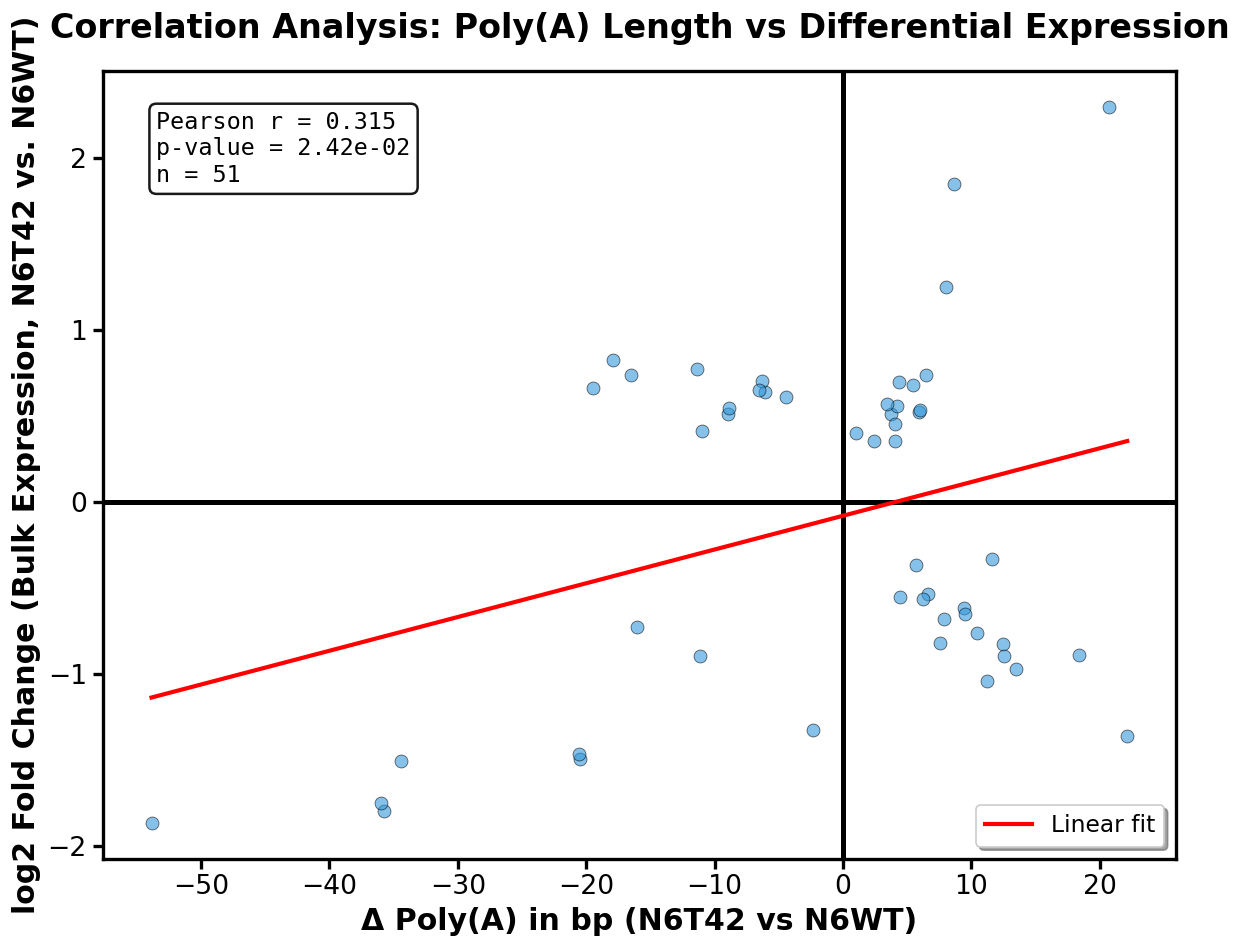


✓ Enhanced plot created with 51 data points
✓ Correlation coefficient: r = 0.315
✓ Statistical significance: p = 2.42e-02


In [ ]:


# Filter by adjusted p-value
filtered = merged.copy()
filtered = merged[merged['p_value'] < 0.05]
filtered = filtered[filtered['padjBulk'] < 0.05]

# Extract the two series and remove NaN values
x = filtered["delta_pT_N6T42_vs_N6WT"]
y = filtered["log2FoldChangeBulk"]

# Create a mask for non-NaN values in both series
valid_mask = x.notna() & y.notna()
x_clean = x[valid_mask]
y_clean = y[valid_mask]

print(f"Total points: {len(filtered)}, Valid points: {len(x_clean)}")

# Pearson correlation
r, pval = stats.pearsonr(x_clean, y_clean)
print(f"Pearson r = {r:.3f}, p = {pval:.3e}")

# Create figure with white background
fig, ax = plt.subplots(figsize=(10, 8), dpi=120, facecolor='white')
ax.set_facecolor('white')

# Main scatter plot - single color
scatter = ax.scatter(x_clean, y_clean,
                     c='#3498DB',
                     alpha=0.6,
                     s=60,
                     edgecolor='black',
                     linewidth=0.5,
                     zorder=3)

# Regression line
m, b = np.polyfit(x_clean, y_clean, 1)
x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
y_line = m * x_line + b

ax.plot(x_line, y_line, color='red', linestyle='-', linewidth=2.5,
        label='Linear fit', zorder=2)

# Reference lines
ax.axhline(0, color='black', linestyle='-', linewidth=3, zorder=1)
ax.axvline(0, color='black', linestyle='-', linewidth=3, zorder=1)

# Labels and title
ax.set_xlabel('Δ Poly(A) in bp (N6T42 vs N6WT)', fontsize=18, fontweight='bold')
ax.set_ylabel('log2 Fold Change (Bulk Expression, N6T42 vs. N6WT)', fontsize=18, fontweight='bold')
ax.set_title('Correlation Analysis: Poly(A) Length vs Differential Expression',
             fontsize=20, fontweight='bold', pad=20)

# Add statistics box
stats_text = f'Pearson r = {r:.3f}\np-value = {pval:.2e}\nn = {len(x_clean)}'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=1.5)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props, family='monospace')



# Legend
ax.legend(loc='lower right', frameon=True, fancybox=True, shadow=True, fontsize=14)

# Make axes black and thicker
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

# Larger tick labels
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6, color='black')

# Remove grid
ax.grid(False)

# Save the figure
plt.savefig(data_path + '/Plots/N6T42vsN6WT_pt_lengthvsAbundance_nolabel.png', dpi=600, bbox_inches='tight')

# Tight layout
plt.tight_layout()
plt.show()

print(f"\n Enhanced plot created with {len(x_clean)} data points")
print(f" Correlation coefficient: r = {r:.3f}")
print(f" Statistical significance: p = {pval:.2e}")

Total points: 51, Valid points: 51
Pearson r = 0.315, p = 2.418e-02


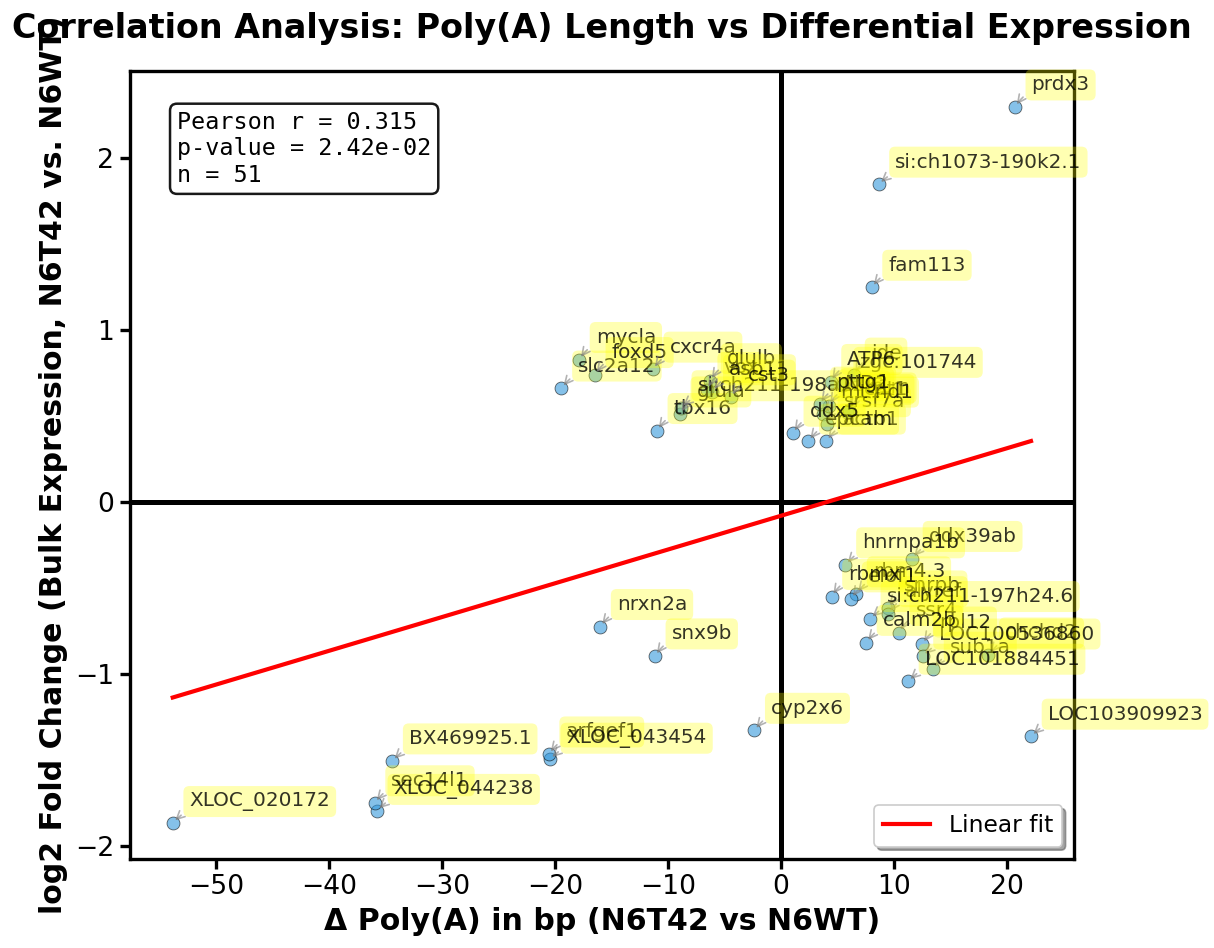


✓ Enhanced plot created with 51 data points
✓ Correlation coefficient: r = 0.315
✓ Statistical significance: p = 2.42e-02


In [ ]:
# with gene labels

# Filter by adjusted p-value
filtered = merged.copy()
filtered = merged[merged['p_value'] < 0.05]
filtered = filtered[filtered['padjBulk'] < 0.05]

# Extract the two series and remove NaN values
x = filtered["delta_pT_N6T42_vs_N6WT"]
y = filtered["log2FoldChangeBulk"]

# Create a mask for non-NaN values in both series
valid_mask = x.notna() & y.notna()
x_clean = x[valid_mask]
y_clean = y[valid_mask]

print(f"Total points: {len(filtered)}, Valid points: {len(x_clean)}")

# Pearson correlation
r, pval = stats.pearsonr(x_clean, y_clean)
print(f"Pearson r = {r:.3f}, p = {pval:.3e}")

# Create figure with white background
fig, ax = plt.subplots(figsize=(10, 8), dpi=120, facecolor='white')
ax.set_facecolor('white')

# Main scatter plot - single color
scatter = ax.scatter(x_clean, y_clean,
                     c='#3498DB',
                     alpha=0.6,
                     s=60,
                     edgecolor='black',
                     linewidth=0.5,
                     zorder=3)

# Add gene labels for points far from origin (top 155 most extreme)
distances = np.sqrt(x_clean**2 + y_clean**2)
top_indices = distances.nlargest(155).index

for idx in top_indices:
    gene = filtered.loc[idx, "Gene"]
    xi = x.loc[idx]
    yi = y.loc[idx]
    ax.annotate(gene,
                xy=(xi, yi),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=12,
                alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3, edgecolor='none'),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                               color='gray', alpha=0.6, lw=1))

# Regression line
m, b = np.polyfit(x_clean, y_clean, 1)
x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
y_line = m * x_line + b

ax.plot(x_line, y_line, color='red', linestyle='-', linewidth=2.5,
        label='Linear fit', zorder=2)

# Reference lines
ax.axhline(0, color='black', linestyle='-', linewidth=3, zorder=1)
ax.axvline(0, color='black', linestyle='-', linewidth=3, zorder=1)

# Labels and title
ax.set_xlabel('Δ Poly(A) in bp (N6T42 vs N6WT)', fontsize=18, fontweight='bold')
ax.set_ylabel('log2 Fold Change (Bulk Expression, N6T42 vs. N6WT)', fontsize=18, fontweight='bold')
ax.set_title('Correlation Analysis: Poly(A) Length vs Differential Expression',
             fontsize=20, fontweight='bold', pad=20)

# Add statistics box
stats_text = f'Pearson r = {r:.3f}\np-value = {pval:.2e}\nn = {len(x_clean)}'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=1.5)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props, family='monospace')



# Legend
ax.legend(loc='lower right', frameon=True, fancybox=True, shadow=True, fontsize=14)

# Make axes black and thicker
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

# Larger tick labels
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6, color='black')

# Remove grid
ax.grid(False)

# Save the figure
plt.savefig(data_path + '/Plots/N6T42vsN6WT_pt_lengthvsAbundance_label.png', dpi=600, bbox_inches='tight')

# Tight layout
plt.tight_layout()
plt.show()

print(f"\n Enhanced plot created with {len(x_clean)} data points")
print(f" Correlation coefficient: r = {r:.3f}")
print(f" Statistical significance: p = {pval:.2e}")



### Differential polyadenylation by counts


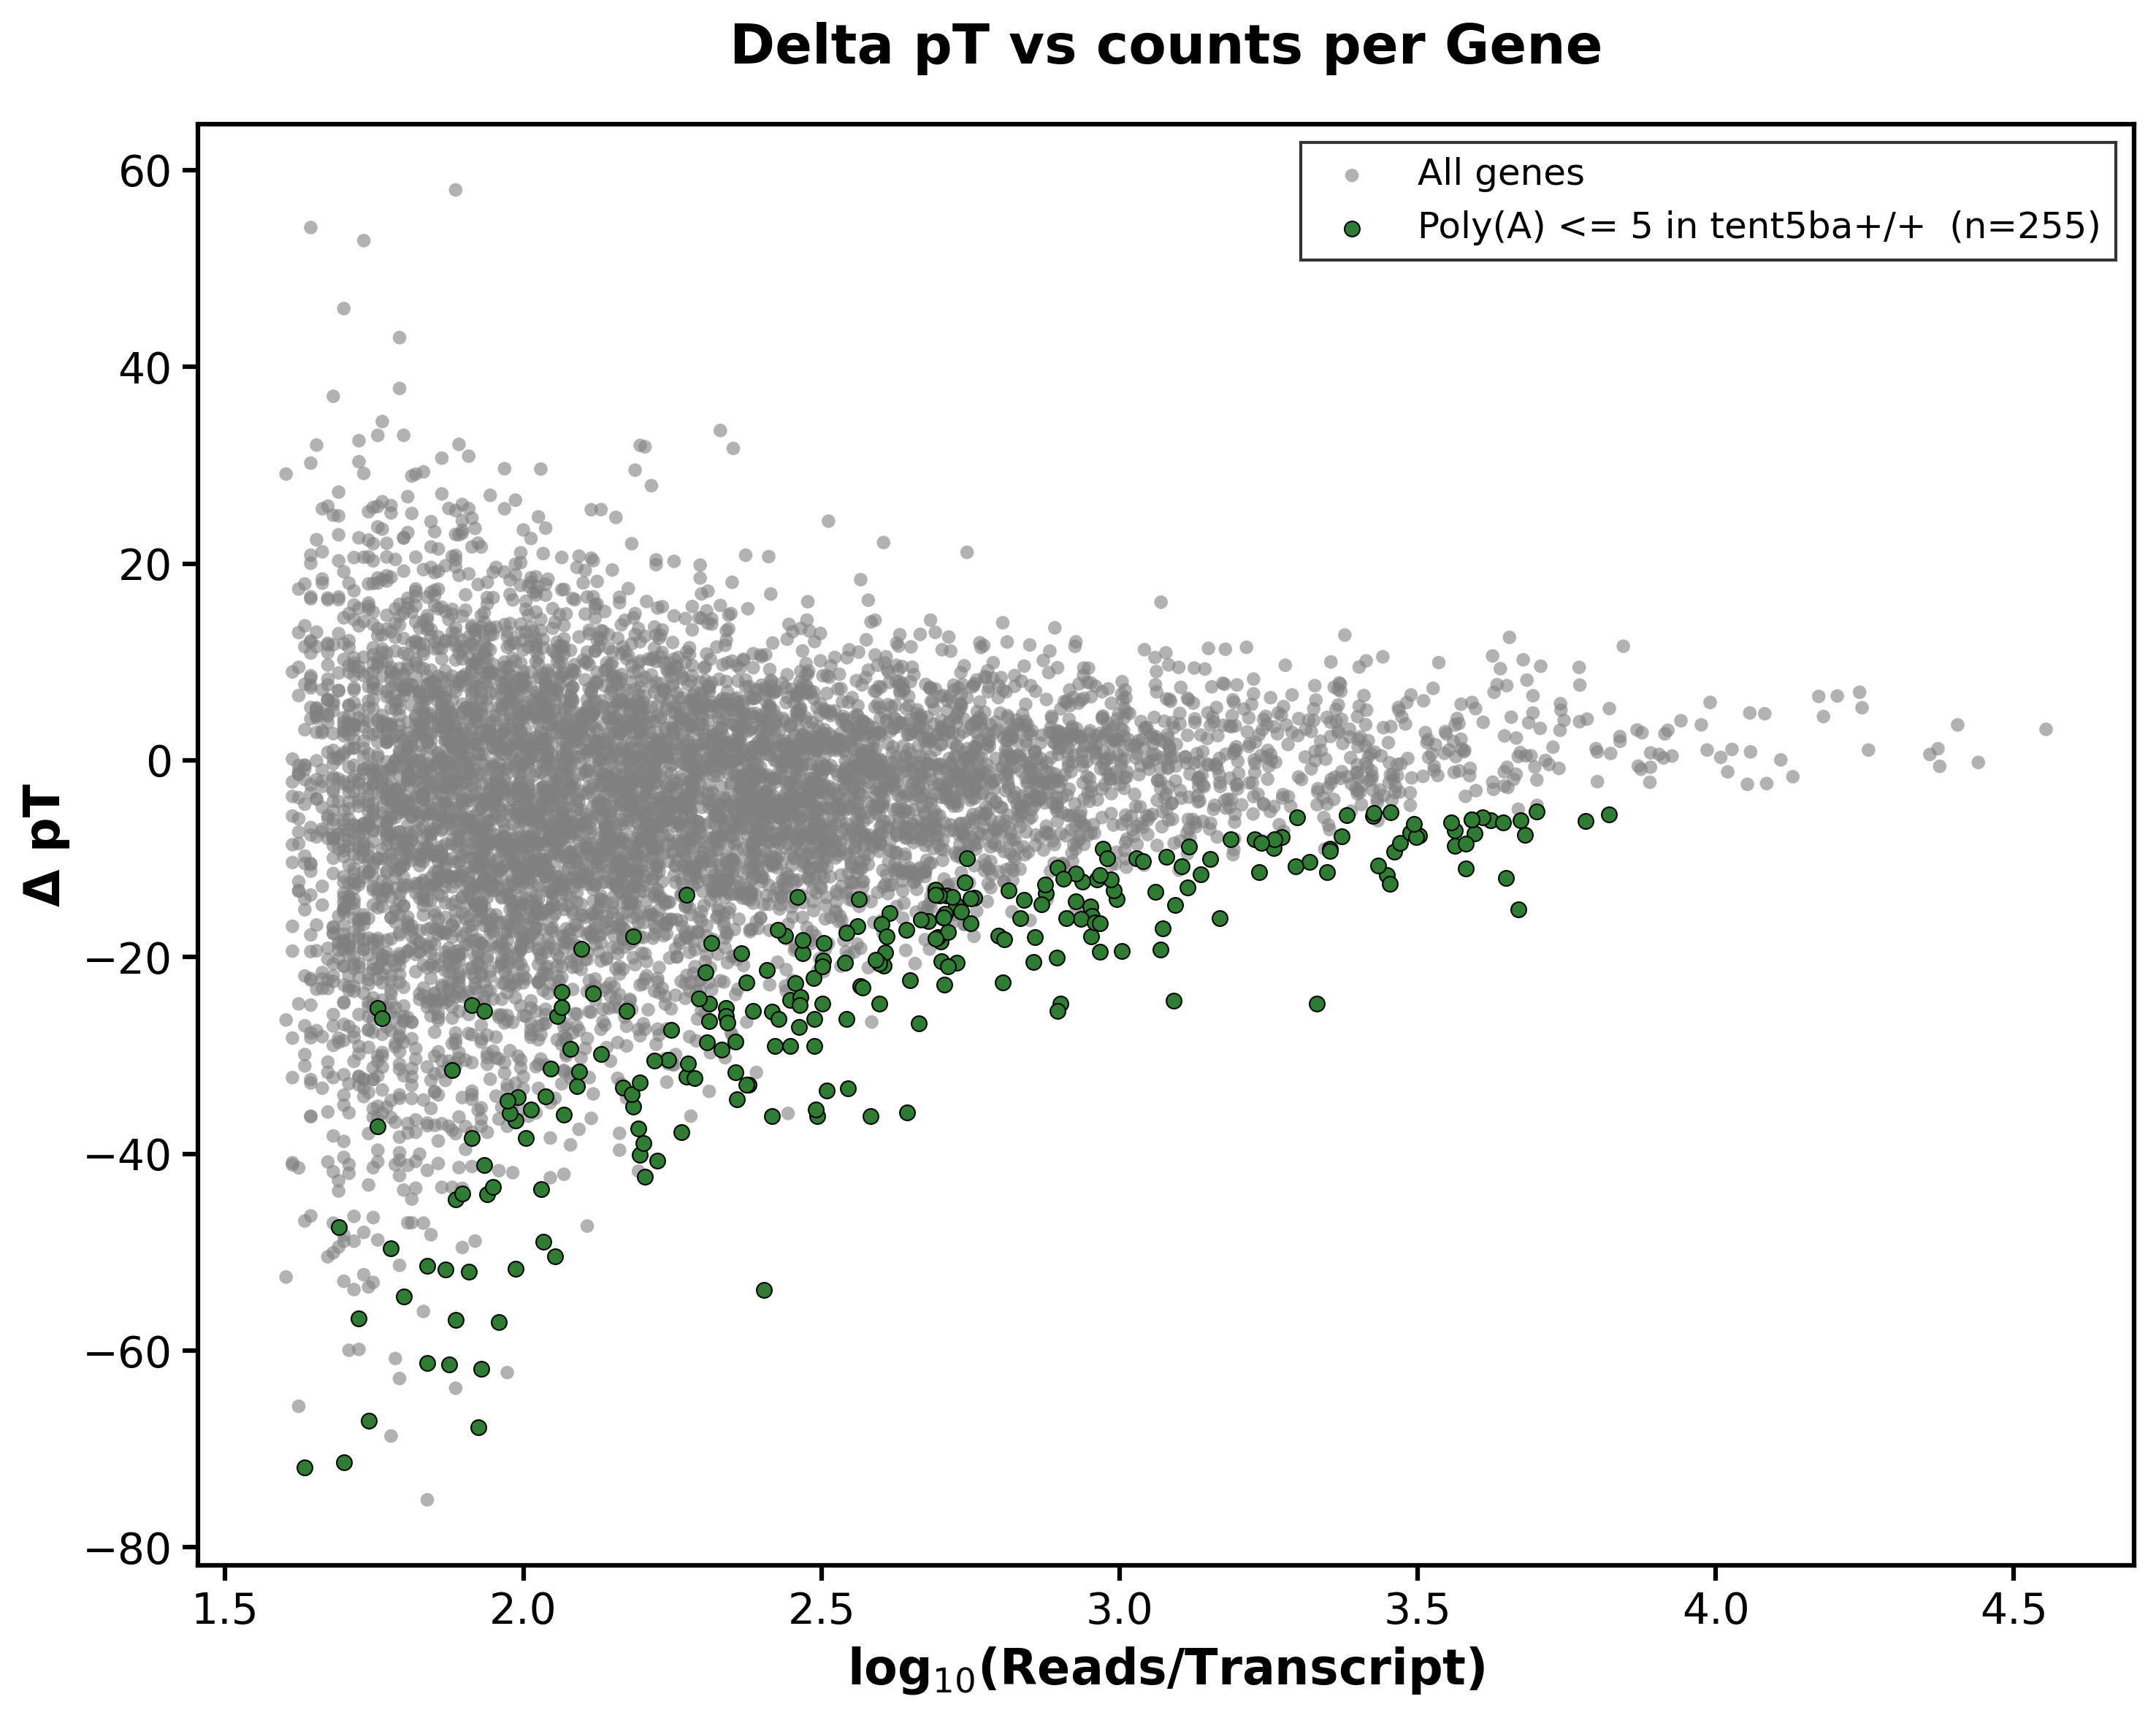

Number of significant genes with decreased pT: 255
Total significant genes: 505


In [ ]:


# Set parametres
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5

sig = merged['BH_adjusted_p_value'] < 0.1

# Separate significant genes by direction
sig_decrease = sig & (merged['delta_pT_N6T42_vs_N6WT'] < -5)


# Create figure with high DPI
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

# Plot
ax.scatter(np.log10(merged['Total reads']),
           merged['delta_pT_N6T42_vs_N6WT'],
           alpha=0.6,
           label='All genes',
           s=20,
           color='#808080',
           edgecolors='none')

# Plot significant genes with negative delta pT (dark green)
ax.scatter(np.log10(merged.loc[sig_decrease, 'Total reads']),
           merged.loc[sig_decrease, 'delta_pT_N6T42_vs_N6WT'],
           color='#2E7D32',  # Dark green
           label=f'Poly(A) <= 5 in tent5ba+/+  (n={sig_decrease.sum()})',
           s=25,
           edgecolors='black',
           linewidths=0.5,
           zorder=5)


# Labels
ax.set_xlabel("log$_{10}$(Reads/Transcript)", fontsize=16, fontweight='bold')
ax.set_ylabel("Δ pT", fontsize=16, fontweight='bold')
ax.set_title("Delta pT vs counts per Gene", fontsize=18, fontweight='bold', pad=20)

# Tick labels
ax.tick_params(labelsize=14)

# Legend
ax.legend(fontsize=12,
          frameon=True,
          fancybox=False,
          edgecolor='black',
          loc='best')


# Tight layout
plt.tight_layout()

# Save as high-res image
plt.savefig(data_path + '/Plots/N6WTN6t42delta_pT_vs_countsBHp1downwithoutline.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(data_path + '/Plots/N6WTN6T42delta_pT_vs_countsBHp1downwithoutline.pdf', bbox_inches='tight', facecolor='white')

plt.show()

print(f"Number of significant genes with decreased pT: {sig_decrease.sum()}")

print(f"Total significant genes: {sig.sum()}")

### Beeswarm N6WT vs N6T42 and H18WT vs H18T42

In [ ]:
#import pandas as pd
#import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
#import numpy as np

In [ ]:
df = pd.read_csv(data_path + '/CombinedR1R2_PolyAtable_annotated.csv', sep = '\t')
df

/tmp/ipykernel_10205/891892265.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Chris/Nano3pSeq/PostPolyTailor/CombinedR1R2_table_annotated.csv', sep = '\t')


,read_id,barcode,mapq,filter,pt_length,per_base,primer_end,pt_start,before_pt,pt_seq,...,exons,additional,comment,Gene,Group,Genotype,Method,Condition,Batch,Adjusted_pt_length
0,b08e7e33-7610-48f3-8ed9-f1a1293ed16f,SQK-NBD114-24_barcode07,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,39132-39280,gene_assignment=unique; PolyA=False; Classific...,NaN,XLOC_043623,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
1,1b514c91-eccd-4fe6-b857-1093e4061fcd,SQK-NBD114-24_barcode11,60,not_continuous,-0.2,3.9,100,101,GAGGCAGAGG,TTTTT,...,2235-3171,Classification=intergenic;,NaN,NaN,Hyp_rRNA_T42_2a,Tent5ba42,Hypoxia18,Hypoxia18,Batch1,1.750
2,8ab9bff2-43b2-4696-a238-b6c72f444674,SQK-NBD114-24_barcode07,18,no_primer,0.0,0.0,0,0,NaN,NaN,...,2866-3405,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
3,7f1adb2e-6d1c-483d-8bfc-037643264136,SQK-NBD114-24_barcode08,49,not_continuous,-0.2,2.6,144,149,CAGAGTCTGA,TTTT,...,2877-3141,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_2a,Wildtype,Hypoxia18,Hypoxia18,Batch1,1.750
4,4dd554ec-22ab-4fc3-84d9-0ed13e4c9fa3,SQK-NBD114-24_barcode07,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,3095-3559,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27307111,eddc7366-6312-47a7-b918-5beedcc5abe7,SQK-NBD114-24_barcode13,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,16399-16596,gene_assignment=inconsistent_non_intronic; Pol...,NaN,NaN,Hyp_rRNA_WT_1,Wildtype,Hypoxia18,Hypoxia18,Batch2,2.000
27307112,cdbb438e-243c-4122-a166-959b0145e540,SQK-NBD114-24_barcode05,60,OK,10.8,3.5,104,104,CAGAGCAGAG,TTTTTTTTTTTTTTTTTATT,...,16400-16515,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Norm_rRNA_T42_2,Tent5ba42,Normoxia6hpf,Normoxia6hpf,Batch2,15.500
27307113,a25e139b-ff92-4766-8e3b-86a37959dea8,SQK-NBD114-24_barcode16,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,16402-16560,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Hyp_rRNA_T42_1,Tent5ba42,Hypoxia18,Hypoxia18,Batch2,2.000
27307114,4d397346-f635-44df-b346-b6588a666674,SQK-NBD114-24_barcode04,60,OK,12.9,2.9,103,103,CAGAGCAGAG,TTATTTTTTTTTTTTTT,...,16403-16522,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Norm_rRNA_T42_1,Tent5ba42,Normoxia6hpf,Normoxia6hpf,Batch2,18.125


In [ ]:
df = df[df["filter"] == 'OK']

df = df[df["Gene"].notna()]


In [ ]:
genesofinterest = ('rpl10a', 'rps19', 'rps23', 'fbxo5', 'aurka', 'ccnb1', 'slc2a8', 'slc2a12', 'sox32', 'tbx16', 'apela', 'gpc4', 'fzd7a', 'hes6', 'dvl2', 'id1','ints12', 'ppdpfb', 'vox', 'cst3')

In [ ]:
filtered = df[df['Gene'].isin(genesofinterest)]
filtered

,read_id,barcode,mapq,filter,pt_length,per_base,primer_end,pt_start,before_pt,pt_seq,...,exons,additional,comment,Gene,Group,Genotype,Method,Condition,Batch,Adjusted_pt_length
17556,03e80a8c-3dbd-4a60-aea1-9f122402886f,SQK-NBD114-24_barcode08,60,OK,45.0,2.1,113,113,CAGAGCAGAG,TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT,...,"19667184-19668315,19670672-19670761,19673492-1...",gene_assignment=inconsistent; PolyA=True; Clas...,NaN,apela,Hyp_rRNA_WT_2a,Wildtype,rRNA,Hypoxia18,Batch1,58.250
17557,80a0fc37-4d6e-4a41-ac7e-8f1b5cfa79fd,SQK-NBD114-24_barcode10,60,OK,27.1,2.4,106,106,CAGAGCAGAG,TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT,...,"19667184-19668315,19670672-19670761,19673492-1...",gene_assignment=inconsistent; PolyA=True; Clas...,NaN,apela,Hyp_rRNA_T42_1a,Tent5ba42,rRNA,Hypoxia18,Batch1,35.875
17560,118afd2c-386e-40cc-bf73-b67db0051d95,SQK-NBD114-24_barcode10,60,OK,14.6,2.2,110,110,CAGAGCAGAG,TTTTTTTTTTTTTT,...,"19667184-19668315,19670672-19670761,19673492-1...",gene_assignment=inconsistent; PolyA=True; Clas...,NaN,apela,Hyp_rRNA_T42_1a,Tent5ba42,rRNA,Hypoxia18,Batch1,20.250
17563,949e0bb2-711c-49f5-a28e-7c423adf7939,SQK-NBD114-24_barcode12,60,OK,40.0,2.4,100,100,CAGAGCAGAG,TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT,...,"19667184-19668315,19670672-19670761,19673492-1...",gene_assignment=inconsistent; PolyA=True; Clas...,NaN,apela,Hyp_rRNA_T42_3a,Tent5ba42,rRNA,Hypoxia18,Batch1,52.000
17566,0d7b301c-3eff-465c-8894-b688ed852773,SQK-NBD114-24_barcode12,60,OK,2.9,3.0,103,103,CAGAGCAGAG,TTTTTTTTTTTT,...,"19667184-19668315,19670672-19670761,19673492-1...",gene_assignment=inconsistent; PolyA=True; Clas...,NaN,apela,Hyp_rRNA_T42_3a,Tent5ba42,rRNA,Hypoxia18,Batch1,5.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26482300,1af10619-a9b7-4daa-b252-905d4a0cf031,SQK-NBD114-24_barcode15,60,OK,0.7,2.6,108,108,CAGAGCAGAG,TTTTTTT,...,13354075-13354863,gene_assignment=unique; PolyA=False; Classific...,NaN,fzd7a,Hyp_rRNA_WT_3,Wildtype,rRNA,Hypoxia18,Batch2,2.875
26482302,e6fad682-f909-4487-a306-ed6ed267c836,SQK-NBD114-24_barcode15,60,OK,0.2,2.0,103,103,CAGAGCAGAG,TT,...,13354095-13355023,gene_assignment=unique; PolyA=False; Classific...,NaN,fzd7a,Hyp_rRNA_WT_3,Wildtype,rRNA,Hypoxia18,Batch2,2.250
26482308,85bb647c-ca82-41c4-8291-86c6a626695d,SQK-NBD114-24_barcode17,60,OK,80.0,2.8,81,81,CAGAGCAGAG,TTTTTTTTTTTTTTTTTT,...,13354358-13355870,gene_assignment=inconsistent_non_intronic; Pol...,NaN,fzd7a,Hyp_rRNA_T42_2,Tent5ba42,rRNA,Hypoxia18,Batch2,102.000
26482316,3d491b8d-a13e-4396-b753-00b7313c9fcb,SQK-NBD114-24_barcode06,60,OK,0.9,2.6,112,112,CAGAGCAGAG,TT,...,13354486-13355006,gene_assignment=unique; PolyA=False; Classific...,NaN,fzd7a,Norm_rRNA_T42_3,Tent5ba42,rRNA,Normoxia6hpf,Batch2,3.125


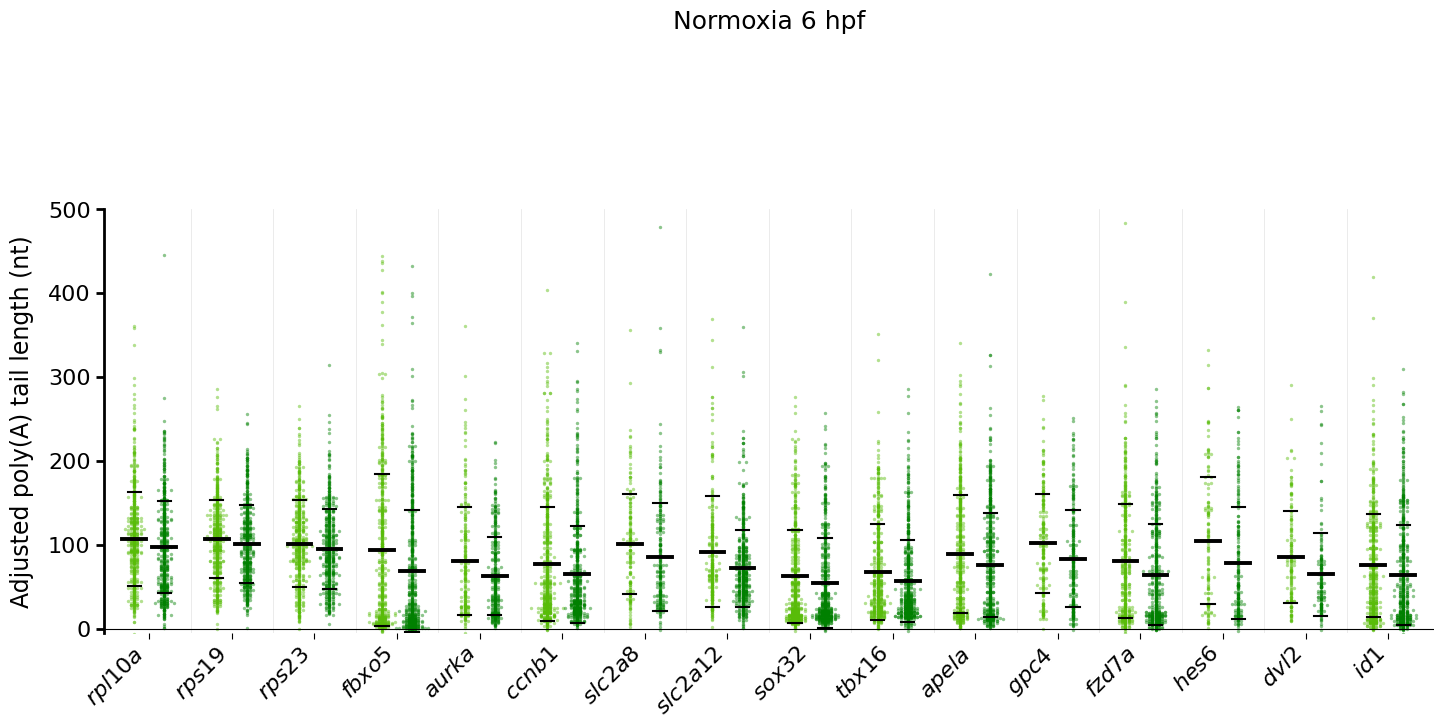

Saved → polya_normoxia_verticalwithoutlegene.pdf  (DPI=300)


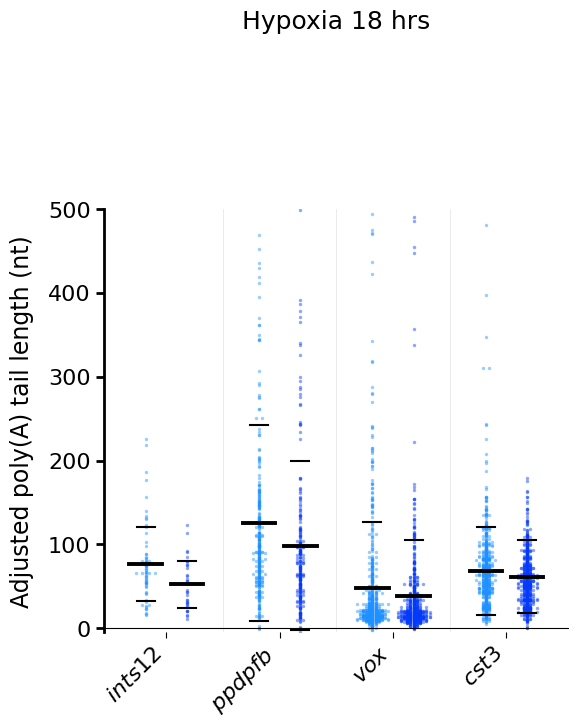

Saved → polya_hypoxia_verticalwithoutlegened.pdf  (DPI=300)


In [ ]:


#  gene lists
NORM_GENES = [
    'rpl10a','rps19','rps23','fbxo5','aurka','ccnb1',
    'slc2a8','slc2a12','sox32','tbx16','apela','gpc4',
    'fzd7a','hes6','dvl2','id1',
]
HYP_GENES = ['ints12','ppdpfb','vox','cst3']

NORM_COND = 'Normoxia6hpf'
HYP_COND  = 'Hypoxia18'
WT_GENO   = 'Wildtype'
MUT_GENO  = 'Tent5ba42'

NORM_WT_COL  = '#58bc08'
NORM_MUT_COL = 'g'
HYP_WT_COL   = 'dodgerblue'
HYP_MUT_COL  = '#0339f8'

MAX_PTS  = 600
DOT_S    = 6
ALPHA    = 0.45
SUB_GAP  = 0.20
GENE_GAP = 0.55

FS_TICK   = 16
FS_LABEL  = 17
FS_TITLE  = 18
FS_MEAN   = 11
FS_LEGEND = 14
FS_PVAL   = 11

Y_SPINE_LW = 2.0
Y_TICK_W   = 2.0
Y_TICK_LEN = 6
X_SPINE_LW = 0.8
X_TICK_W   = 0.8
X_TICK_LEN = 4

DPI = 300   # high-res export


def build_pval_dict(stats_df):
    return dict(zip(
        stats_df['Gene'].str.lower(),
        stats_df['BH_adjusted_p_value']
    ))

norm_pvals = build_pval_dict(norm_stats)
hyp_pvals  = build_pval_dict(hyp_stats)

#  helpers
def beeswarm_x(vals, centre_x, dot_radius_data):
    if len(vals) == 0:
        return np.array([])
    bin_w = dot_radius_data * 3.0
    sorted_idx = np.argsort(vals)
    sorted_v   = vals[sorted_idx]
    x_out      = np.zeros(len(vals))
    i = 0
    while i < len(sorted_v):
        j = i
        while j < len(sorted_v) and sorted_v[j] - sorted_v[i] < bin_w:
            j += 1
        n       = j - i
        offsets = (np.arange(n) - (n - 1) / 2.0) * dot_radius_data * 2.2
        x_out[sorted_idx[i:j]] = centre_x + offsets
        i = j
    return x_out

def nudge_labels(positions, values, min_gap):
    paired = sorted(zip(positions, values), key=lambda t: t[0])
    adj    = [v for _, v in paired]
    for i in range(1, len(adj)):
        if abs(paired[i][0] - paired[i-1][0]) < 0.3:
            if adj[i] - adj[i-1] < min_gap:
                adj[i] = adj[i-1] + min_gap
    orig_order = {pos: val for pos, val in zip([p for p, _ in paired], adj)}
    return [orig_order[p] for p in positions]

def fmt_pval(p):
    exponent = int(np.floor(np.log10(abs(p)))) if p > 0 else 0
    mantissa = p / 10**exponent
    return f'{mantissa:.1f}×10$^{{{exponent}}}$'

#  figure builder
def make_figure(genes, cond_val, wt_col, mut_col, cond_label, fname):
    n_genes = len(genes)

    fig_w    = max(6, n_genes * GENE_GAP * 1.7 + 2.2)
    # annotation panel height is fixed; swarm panel height scales with data
    ann_h    = 2.2   # inches for annotation panel above plot
    swarm_h  = 5.5
    fig_h    = swarm_h + ann_h

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs  = gridspec.GridSpec(
        2, 1,
        height_ratios=[ann_h, swarm_h],
        hspace=0.0,
        figure=fig
    )
    ax_ann   = fig.add_subplot(gs[0])   # top: means, p-values, legend
    ax_swarm = fig.add_subplot(gs[1])   # bottom: beeswarm

    gene_centres = [i * GENE_GAP for i in range(n_genes)]
    wt_cols_x    = [c - SUB_GAP / 2 for c in gene_centres]
    mut_cols_x   = [c + SUB_GAP / 2 for c in gene_centres]

    x_lo = -GENE_GAP * 0.55
    x_hi = (n_genes - 1) * GENE_GAP + GENE_GAP * 0.55

    for ax in [ax_ann, ax_swarm]:
        ax.set_xlim(x_lo, x_hi)

    data_span    = x_hi - x_lo
    fig_w_pts    = fig_w * 72 * 0.82
    pts_per_data = fig_w_pts / data_span
    dot_radius_d = (np.sqrt(DOT_S) / pts_per_data) * 0.9

    cond_df     = filtered[filtered['Condition'] == cond_val]

    #  collect per-gene stats
    gene_data = {}   # gene -> {geno: (all_vals, mean, sd)}
    y_max_all = 0

    for gene in genes:
        gene_df = cond_df[cond_df['Gene'] == gene]
        gene_data[gene] = {}
        for geno in [WT_GENO, MUT_GENO]:
            vals = gene_df[gene_df['Genotype'] == geno]['Adjusted_pt_length'].dropna().values
            gene_data[gene][geno] = vals
            if len(vals):
                y_max_all = max(y_max_all, vals.max())

    #  draw swarm panel
    for i, gene in enumerate(genes):
        for col_x, color, geno in [
            (wt_cols_x[i],  wt_col,  WT_GENO),
            (mut_cols_x[i], mut_col, MUT_GENO),
        ]:
            all_vals = gene_data[gene][geno]
            if len(all_vals) == 0:
                continue

            plot_vals = all_vals
            if len(all_vals) > MAX_PTS:
                rng       = np.random.default_rng(42)
                plot_vals = rng.choice(all_vals, MAX_PTS, replace=False)

            x_pos = beeswarm_x(plot_vals, col_x, dot_radius_d)
            ax_swarm.scatter(x_pos, plot_vals, s=DOT_S, color=color,
                             alpha=ALPHA, linewidths=0, zorder=2)
            if len(all_vals) < 2:
                continue

            mean = all_vals.mean()
            sd   = all_vals.std()
            cap  = SUB_GAP * 0.22

            # SD caps only (no middle vertical line)
            for ye in [mean - sd, mean + sd]:
                ax_swarm.plot(
                    [col_x - cap, col_x + cap],
                    [ye, ye],
                    color='black',
                    lw=1.5,
                    zorder=4
                )

            # Mean line
            ax_swarm.plot(
                [col_x - cap * 1.8, col_x + cap * 1.8],
                [mean, mean],
                color='black',
                lw=2.8,
                zorder=5
            )

        if i < n_genes - 1:
            sep_x = (gene_centres[i] + gene_centres[i + 1]) / 2
            ax_swarm.axvline(sep_x, color='#e8e8e8', lw=0.6, zorder=0)

    # cap y-axis at actual data max + small buffer
    ax_swarm.set_ylim(bottom=-5, top=500)

    # swarm axes styling
    ax_swarm.set_xticks(gene_centres)
    ax_swarm.set_xticklabels(
        [r'$\it{' + g + r'}$' for g in genes],
        fontsize=FS_TICK, rotation=45, ha='right', style='italic'
    )
    ax_swarm.set_ylabel('Adjusted poly(A) tail length (nt)', fontsize=FS_LABEL, labelpad=10)
    ax_swarm.tick_params(axis='y', labelsize=FS_TICK, width=Y_TICK_W, length=Y_TICK_LEN)
    ax_swarm.tick_params(axis='x', width=X_TICK_W, length=X_TICK_LEN)
    ax_swarm.spines['left'].set_linewidth(Y_SPINE_LW)
    ax_swarm.spines['bottom'].set_visible(False)
    ax_swarm.spines['top'].set_visible(False)
    ax_swarm.spines['right'].set_visible(False)
    ax_swarm.axhline(0, color='black', lw=X_SPINE_LW, zorder=3)

    #  annotation panel: means
    ax_ann.set_ylim(0, 1)
    ax_ann.axis('off')


    #  legend in annotation panel (top-right)


    ax_ann.set_title(cond_label, fontsize=FS_TITLE, pad=8)

    plt.savefig(fname, bbox_inches='tight', dpi=DPI)
    plt.show()
    print(f'Saved {fname}  (DPI={DPI})')

#  run
make_figure(
    genes      = NORM_GENES,
    cond_val   = NORM_COND,
    wt_col     = NORM_WT_COL,
    mut_col    = NORM_MUT_COL,
    cond_label = 'Normoxia 6 hpf',
    fname      = 'polya_normoxia_verticalwithoutlegene.pdf'
)

make_figure(
    genes      = HYP_GENES,
    cond_val   = HYP_COND,
    wt_col     = HYP_WT_COL,
    mut_col    = HYP_MUT_COL,
    cond_label = 'Hypoxia 18 hrs',
    fname      = 'polya_hypoxia_verticalwithoutlegened.pdf'
)

## Hypoxia 18 hrs *tent5ba*+/+ vs Hypoxia 18 hrs *tent5ba*-42/-42

### Differential polyadenylation by counts


In [ ]:
# import stats output for this comparison
merged = pd.read_csv(data_path + "/H18WTvsH18T42_Stats/ByCondition_20reads.csv")

In [ ]:
merged

,Gene,Avg_wildtype_Adjusted_pt_length,Avg_Tent5ba42_Adjusted_pt_length,p_value,n_wildtype,n_Tent5ba42,BH_adjusted_p_value,log2FC_T42_vs_WT,delta_pT_T42_vs_WT
0,actb2,75.650388,83.568161,5.625856e-81,11846,10356,4.060180e-77,0.143606,7.917773
1,krt18a.1,84.765298,92.604064,1.525025e-74,10663,8729,5.503053e-71,0.127602,7.838766
2,eef1a1l1,80.512255,86.566294,1.067770e-69,28753,18433,2.568699e-66,0.104597,6.054039
3,krt5,74.799297,81.013429,3.208099e-52,7820,6795,5.788212e-49,0.115136,6.214132
4,hnrnpa0l,63.559151,68.748674,5.612838e-46,12614,8764,8.101571e-43,0.113232,5.189523
...,...,...,...,...,...,...,...,...,...
7212,MYADM,58.213068,60.000000,1.000000e+00,44,50,1.000000e+00,0.043619,1.786932
7213,ercc2,65.521341,73.083333,9.948747e-01,82,57,1.000000e+00,0.157578,7.561992
7214,bsdc1,71.036765,87.238971,1.000000e+00,34,34,1.000000e+00,0.296407,16.202206
7215,slkb,86.361486,97.458333,9.919813e-01,111,57,1.000000e+00,0.174397,11.096847


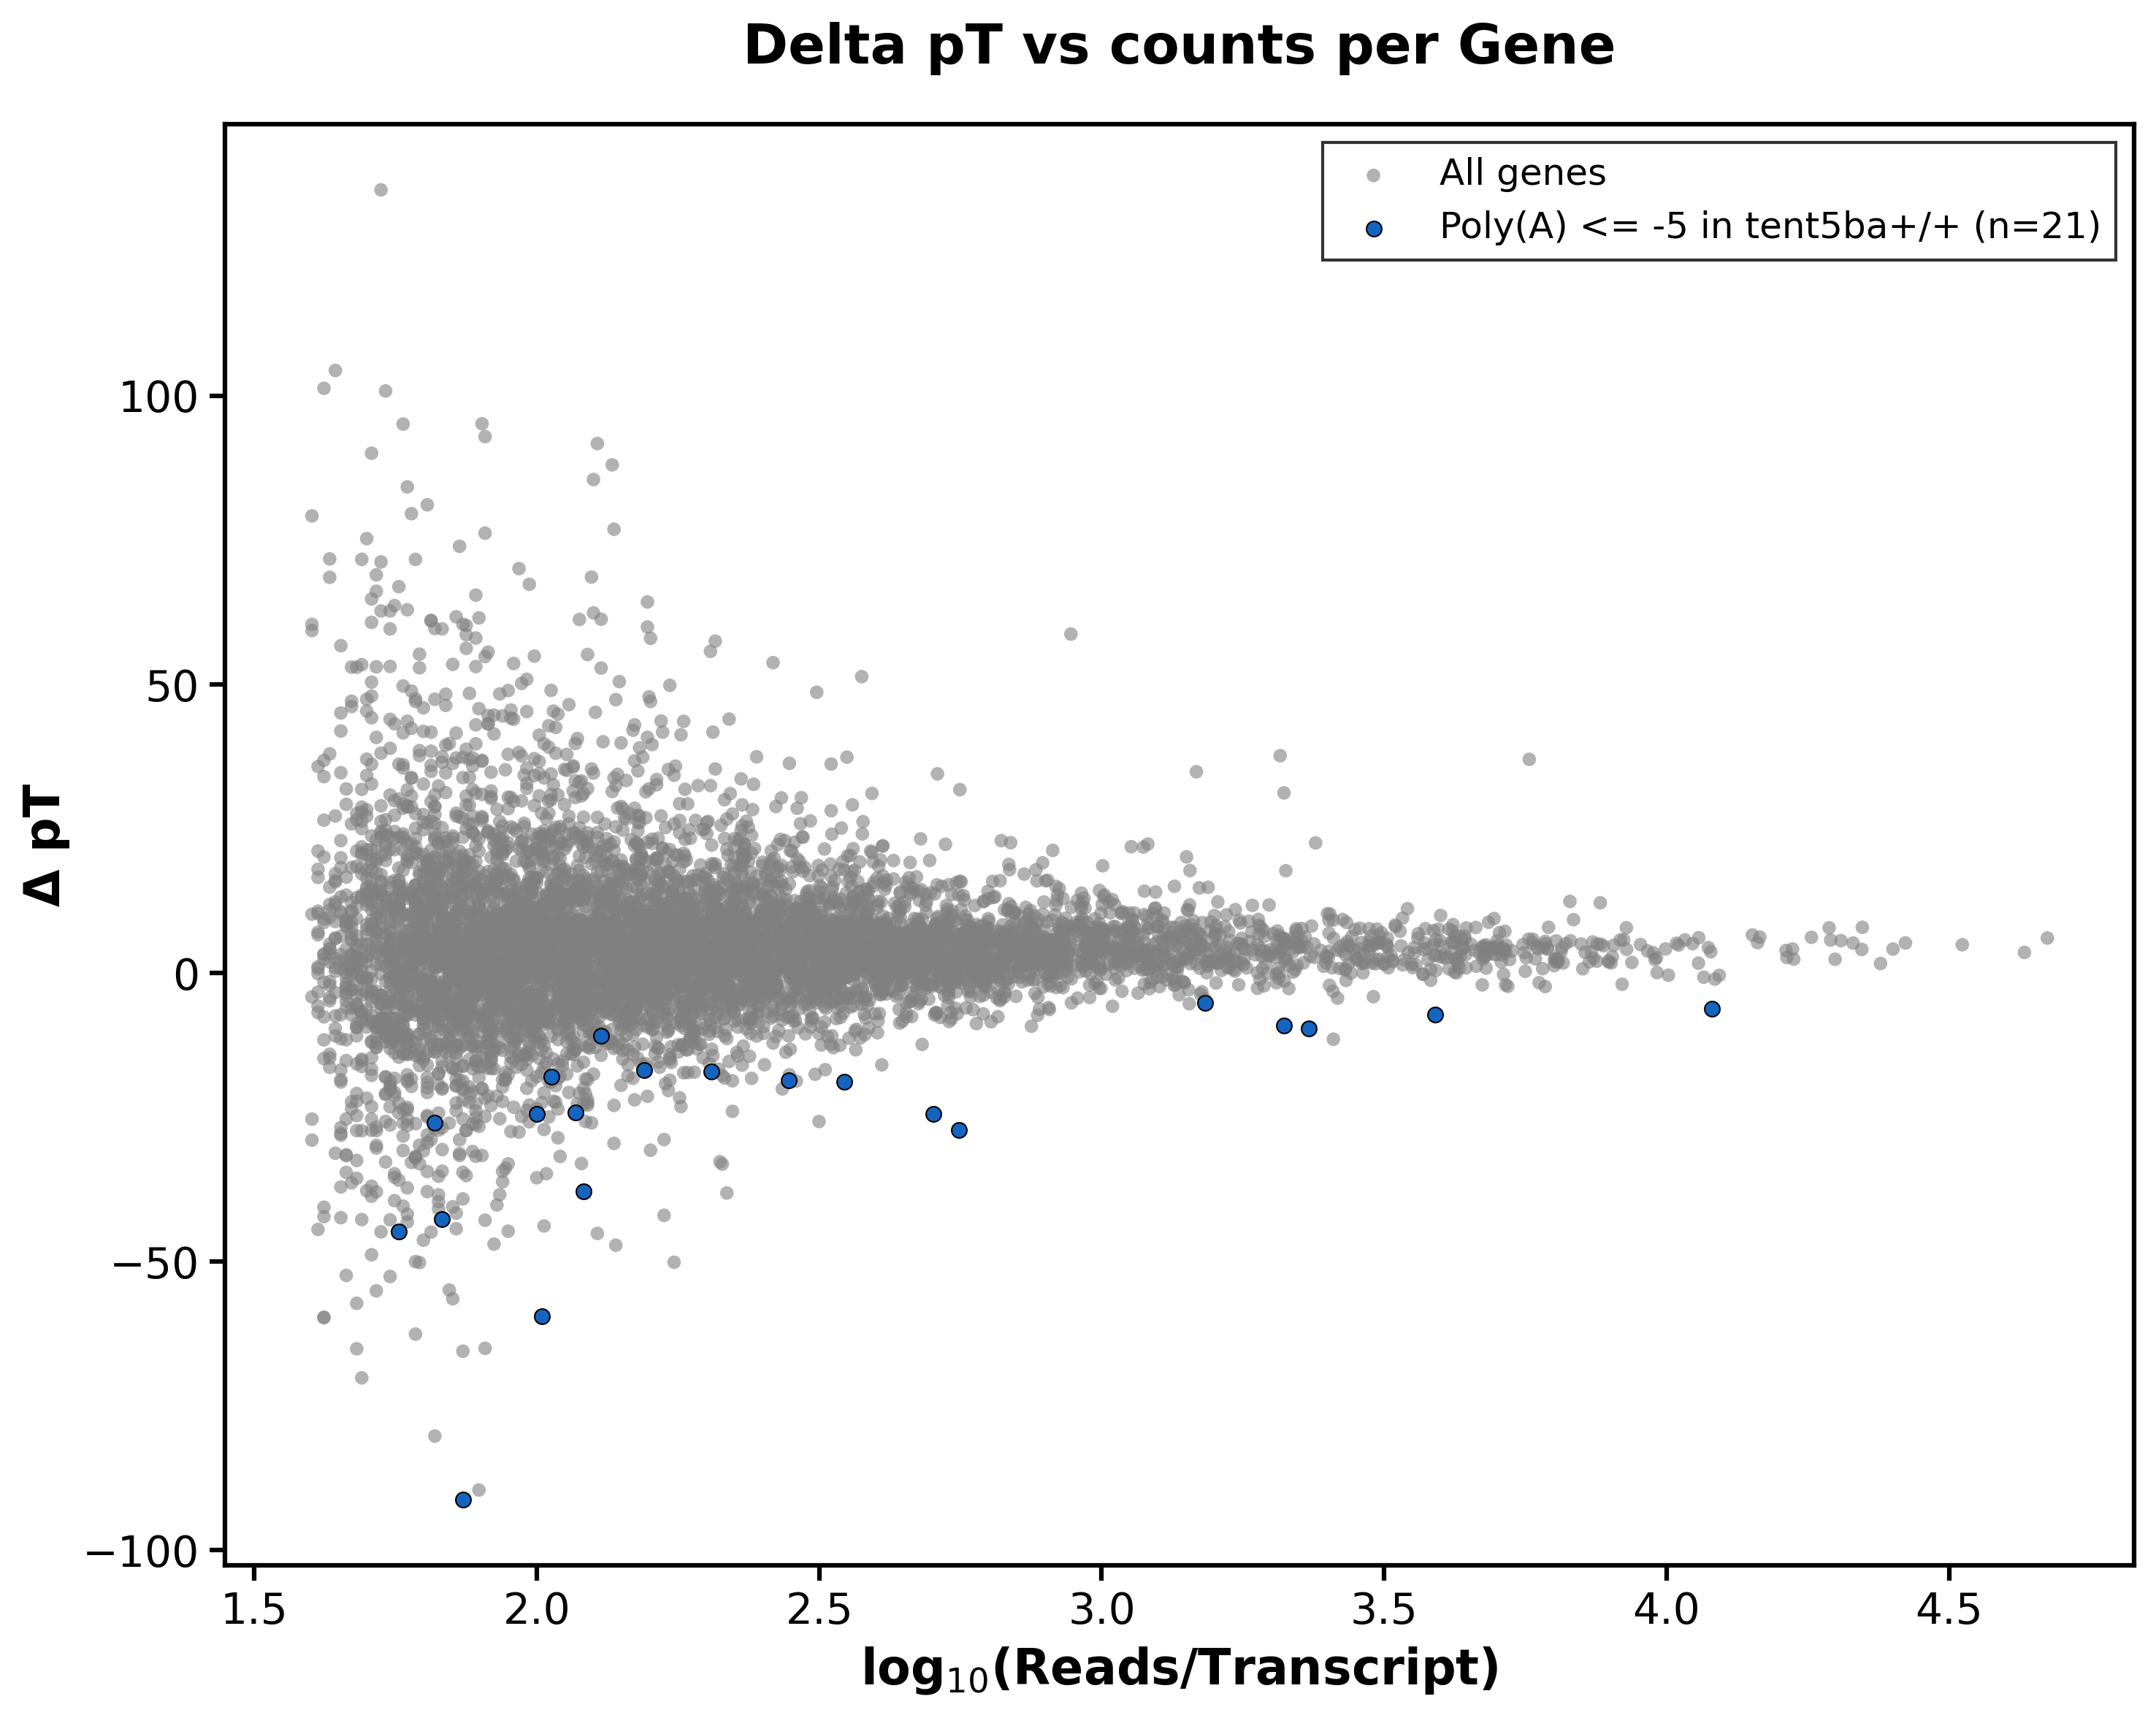

Number of significant genes with decreased pT: 21
Total significant genes: 846


In [ ]:


# Set publication-quality parameters
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5

# Calculate total reads (sum of wildtype and Tent5ba42 reads)
merged['Total_reads'] = merged['n_wildtype'] + merged['n_Tent5ba42']

# Define significant genes
sig = merged['BH_adjusted_p_value'] < 0.1

# Separate significant genes by direction
sig_decrease = sig & (merged['delta_pT_T42_vs_WT'] < -5)

# Create figure with higher DPI
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

# Plot with improved aesthetics
ax.scatter(np.log10(merged['Total_reads']),
           merged['delta_pT_T42_vs_WT'],
           alpha=0.6,
           label='All genes',
           s=20,
           color='#808080',
           edgecolors='none')

# Plot significant genes with negative delta pT (dark blue)
ax.scatter(np.log10(merged.loc[sig_decrease, 'Total_reads']),
           merged.loc[sig_decrease, 'delta_pT_T42_vs_WT'],
           color='#1565C0',  # Dark blue
           label=f'Poly(A) <= -5 in tent5ba+/+ (n={sig_decrease.sum()})',
           s=25,
           edgecolors='black',
           linewidths=0.5,
           zorder=5)



# Labels with larger font
ax.set_xlabel("log$_{10}$(Reads/Transcript)", fontsize=16, fontweight='bold')
ax.set_ylabel("Δ pT", fontsize=16, fontweight='bold')
ax.set_title("Delta pT vs counts per Gene", fontsize=18, fontweight='bold', pad=20)

# Improve tick labels
ax.tick_params(labelsize=14)

# Legend with better styling
ax.legend(fontsize=12,
          frameon=True,
          fancybox=False,
          edgecolor='black',
          loc='best')





# Tight layout
plt.tight_layout()

# Save as high-res image
plt.savefig(data_path + '/Plots/H18WT_H18T42_delta_pT_vs_counts.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(data_path + '/Plots/H18WT_H18T42_delta_pT_vs_counts.pdf', bbox_inches='tight', facecolor='white')  # Vector format

plt.show()

print(f"Number of significant genes with decreased pT: {sig_decrease.sum()}")

print(f"Total significant genes: {sig.sum()}")

### Beeswarm

see other Beeswarm tab